In [7]:
# Run this cell after running the next 6 cells
import os

os.makedirs(models_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

In [1]:
!pip install tensorflow

In [2]:
!pip install sentencepiece

In [3]:
!pip show tensorflow

Name: tensorflow
Version: 2.18.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras


In [4]:
!pip install numpy matplotlib pandas seaborn scikit-learn nltk tensorflow keras beautifulsoup4 spacy openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 46.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 108.1 MB/s eta 0:00:0000:010:01
  Attempting uninstall: blis
    Found existing installation: blis 1.3.0
    Uninstalling blis-1.3.0:
      Successfully uninstalled blis-1.3.0
  Attempting uninstall: thinc
    Found existing installation: t

In [5]:
!python --version

Python 3.11.13


In [6]:
#%%time
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

import seaborn as sns
import re,nltk,json
from bs4 import BeautifulSoup
### ML Librarires--------------------
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
from sklearn.metrics import average_precision_score,roc_auc_score, roc_curve, precision_recall_curve
###-------------------------------------------
from tensorflow.keras.utils import plot_model
np.random.seed(42)
import string, spacy,unicodedata, random
class color: # Text style
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'
import warnings
warnings.filterwarnings('ignore')
### Pretrained Word Embeddings
main_path = "/kaggle/input/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/"
models_path = "/kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/"
results_path = "/kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Results/"
memes_path = "/kaggle/input/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/"

2025-09-16 11:31:09.516483: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758022269.846143      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758022269.940751      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [8]:
!pip install keras_preprocessing==1.1.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.4 MB/s eta 0:00:00


In [9]:
from keras.preprocessing import image
from tensorflow.keras.applications.xception import Xception
from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from keras.applications.densenet import DenseNet121
from keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2
from keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.layers import Dense, GlobalAveragePooling2D, Embedding, LSTM, multiply, concatenate
from keras.models import Model
from keras import preprocessing, Input
from tensorflow import keras
from keras.models import Sequential
#Import from keras_preprocessing not from keras.preprocessing
from keras_preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D
from keras import regularizers, optimizers
from tensorflow.keras.models import load_model
import itertools
from PIL import Image, ImageFile
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Concatenate, Dense, Input, LSTM, Embedding, Dropout, Activation, GRU, Flatten,Reshape,dot,multiply
from tensorflow.keras.layers import Bidirectional, GlobalMaxPool1D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Convolution1D,MaxPooling1D,Conv1D
from tensorflow.keras import initializers, regularizers, constraints, optimizers, layers
from tensorflow.keras.layers import Add, BatchNormalization, Activation, Dropout
from tensorflow.keras.optimizers import RMSprop,Adam,SGD,Nadam
keras.backend.clear_session()

#Dataset Fetching

In [10]:
# remove nrows to fetch all data
train_data = []
train_data = pd.read_excel(main_path + 'train.xlsx')
valid_data = pd.read_excel(main_path + 'valid.xlsx')
test_data = pd.read_excel(main_path + 'test.xlsx')

In [11]:
print("Number of Training Data: ",len(train_data))
print("Number of Validation Data: ",len(valid_data))
print("Number of Test Data: ",len(test_data))

Number of Training Data:  2700
Number of Validation Data:  900
Number of Test Data:  900


In [12]:
train_data['Label'].value_counts()

Label
fake    1350
real    1350
Name: count, dtype: int64

In [13]:
valid_data['Label'].value_counts()

Label
fake    450
real    450
Name: count, dtype: int64

In [14]:
test_data['Label'].value_counts()

Label
real    480
fake    420
Name: count, dtype: int64

In [15]:
## Replace Names
train_data['enc_label'] = train_data['Label'].replace({'real':1,'fake':0})
valid_data['enc_label'] = valid_data['Label'].replace({'real':1,'fake':0})
test_data['enc_label'] = test_data['Label'].replace({'real':1,'fake':0})

## Display Some Data

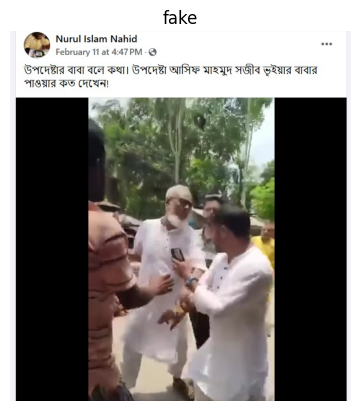

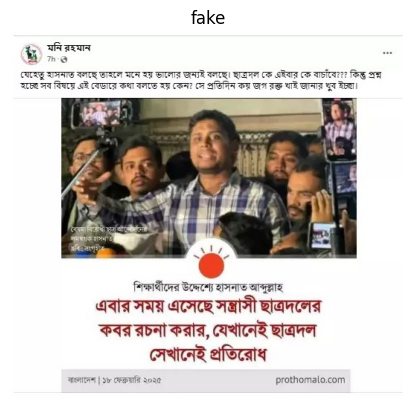

In [16]:
from matplotlib import image as im
for i in range(2):
  data = im.imread(memes_path+'4500 News/'+ train_data['image_name'][i],0)
  plt.figure()
  plt.axis('off')
  plt.imshow(data)
  plt.title(train_data['Label'][i])

'fake'

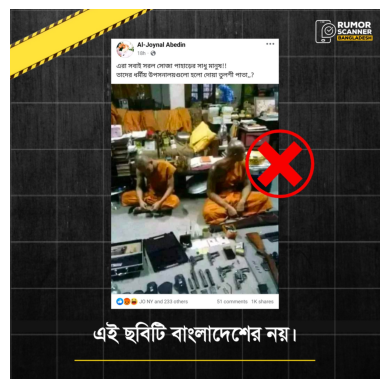

In [17]:
n = 387
from matplotlib import image as im
data = im.imread(memes_path+'4500 News/'+ test_data['image_name'][n],0)
plt.figure()
plt.axis('off')
plt.imshow(data)
#plt.title('Human Damage')
plt.savefig(results_path+"200_negative.png",bbox_inches='tight')
test_data['Label'][n]

#Memes Fetching

In [18]:
## collect image names from the folders
def create_img_array(img_dirct):
    all_imgs = []
    for root, j, files in os.walk(img_dirct):
        for file in files:
            file = root + '' + file
            all_imgs.append(file)
    return all_imgs

def create_img_path(DF, Col_name, img_dir):
    img_path = [img_dir + '' + str(name) for name in DF[Col_name]]
    return img_path


In [19]:
from PIL import Image, ImageFile
from keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

# Function that returns image reading from the path
def get_input(path):
    # Loading image from given path
    # and resizing it to 150*150*3 format
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    img = image.load_img(path, target_size=(150,150))
    return(img)

# Takes in image and preprocess it
def process_input(img):
    # Converting image to array
    img_data = image.img_to_array(img)
    # Adding one more dimension to array
    img_data = np.expand_dims(img_data, axis=0)
    #
    img_data = preprocess_input(img_data)
    return(img_data)


In [20]:
img_dir = "/kaggle/input/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/4500 News/"

# Creating train, test and validation image path
train_img_path = create_img_path(train_data,'image_name', img_dir)
valid_img_path = create_img_path(valid_data,'image_name', img_dir)
test_img_path = create_img_path(test_data,'image_name', img_dir)

In [21]:
# Create an array of training images
errored_data = []
train_images = []
cnt = 1
for i in train_img_path:
  try:
    input_img = get_input(i)
    input_img = process_input(input_img)
    train_images.append(input_img[0])
    cnt = cnt + 1
  except Exception as e:
    print(e)
    errored_data.append(i)

# convert into numpy array
train_image = np.array(train_images)
print(train_image.shape)
print("Number of error: ", len(errored_data))
for ed in errored_data:
  print(ed)

(2700, 150, 150, 3)
Number of error:  0


In [22]:
import pickle as pkl
with open(results_path+'train_image.pkl','wb') as f:
    pkl.dump(train_image, f)

In [23]:
# Create an array of test images
errored_data = []
valid_images = []
for i in valid_img_path:
  try:
    input_img = get_input(i)
    input_img = process_input(input_img)
    valid_images.append(input_img[0])
  except Exception as e:
    errored_data.append(i)

# convert into numpy array
valid_image = np.array(valid_images)
print(valid_image.shape)
print("Errored Data: ", len(errored_data))
for i in errored_data:
  print(i)

(900, 150, 150, 3)
Errored Data:  0


In [24]:
import pickle as pkl
with open(results_path+'valid_image.pkl','wb') as f:
    pkl.dump(valid_image, f)

In [25]:
# Create an array of valid images
errored_data = []
test_images = []
for i in test_img_path:
  try:
    input_img = get_input(i)
    input_img = process_input(input_img)
    test_images.append(input_img[0])
  except Exception as e:
    errored_data.append(i)

# convert into numpy array
test_image = np.array(test_images)
print(test_image.shape)
print("Errored Data: ", len(errored_data))
for i in errored_data:
  print(i)

(900, 150, 150, 3)
Errored Data:  0


In [26]:
import pickle as pkl
with open(results_path+'test_image.pkl','wb') as f:
    pkl.dump(test_image, f)

#Image Fetching

In [28]:
import pickle as pkl

## Train image
with open(results_path+'train_image.pkl','rb') as f:
  train_image = pkl.load(f)
  print("Training Images:-- ",train_image.shape)

## Valid image
with open(results_path+'valid_image.pkl','rb') as f:
  valid_image = pkl.load(f)
  print("Valid Images:-- ",valid_image.shape)

## Test image
with open(results_path+'test_image.pkl','rb') as f:
  test_image = pkl.load(f)
  print("Test Images:-- ",test_image.shape)

Training Images:--  (2700, 150, 150, 3)
Valid Images:--  (900, 150, 150, 3)
Test Images:--  (900, 150, 150, 3)


#Captions Cleaning

In [30]:
stp_path = '/kaggle/input/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Document Categorization/'
stp = open('/kaggle/input/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Document Categorization/bangla_stopwords.txt','r',encoding='utf-8').read().split()

In [31]:
'''
Text Cleaning
'''
def text_cleaning(row):
   if pd.isna(row):
      return ""
   #to remove HTML tags
   text = BeautifulSoup(row, 'html.parser').get_text()
   d = re.sub(r'(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b', '', text, flags=re.MULTILINE) #This line is for removing url
   post = d.replace('\n', '')
   post = post.replace('—', ' ')
   post = post.replace('।', ' ')
   text = ''.join([c for c in post if c not in string.punctuation])
   # to remove special characters
   pattern = r'^\s*|\s\s*'
   text = re.sub(pattern, ' ', text).strip()
   # convert into lower case
   text = text.lower()
   # Stopword
   #result = text.split()
   #text = [word.strip() for word in result if word not in stp ]
   #text =" ".join(text)

   return text

In [32]:
#Removing punctuations
train_data['cleaned'] = train_data['Captions'].apply(text_cleaning)
valid_data['cleaned'] = valid_data['Captions'].apply(text_cleaning)
test_data['cleaned'] = test_data['Captions'].apply(text_cleaning)


## Data samples after cleaning
print("Data samples after cleaning:\n")
for i in range(50):
  print("Original Data:===\n",train_data.Captions[i],"\nCleaned Data:===\n",train_data.cleaned[i], "\nLabel:== ",train_data.Label[i])

Data samples after cleaning:

Original Data:===
 উপদেষ্টার বাবা বলে কথা। উপদেষ্টা আসিফ মাহমুদ সজীব ভৃইয়ার বাবার পাওয়ার কত দেখেন! 
Cleaned Data:===
 উপদেষ্টার বাবা বলে কথা উপদেষ্টা আসিফ মাহমুদ সজীব ভৃইয়ার বাবার পাওয়ার কত দেখেন 
Label:==  fake
Original Data:===
 যেহেতু হাসনাত বলছে তাহলে মনে হয় ভালোর জন্যই বলছে। ছাত্রদল কে এইবার কে বাচাঁবে??? কিন্তু প্রশ্ন হচ্ছে সব বিষয়ে এই বেডারে কথা বলতে হয় কেন? সে প্রতিদিন কয় জগ রক্ত খাই জানার খুব ইচ্ছা। 
Cleaned Data:===
 যেহেতু হাসনাত বলছে তাহলে মনে হয় ভালোর জন্যই বলছে ছাত্রদল কে এইবার কে বাচাঁবে কিন্তু প্রশ্ন হচ্ছে সব বিষয়ে এই বেডারে কথা বলতে হয় কেন সে প্রতিদিন কয় জগ রক্ত খাই জানার খুব ইচ্ছা 
Label:==  fake
Original Data:===
 শোক সংবাদ। খুবই দুঃখের সাথে জানাচ্ছি যে, বীর মুক্তিযোদ্ধা, বিজ্ঞ আইনজীবি স্পষ্ট কথা বলার লোক জেড আই খান পান্না ইন্তেকাল করেছেন, ইন্না-লিল্লাহ ওয়া ইন্না ইলাহি রাজেউন, মহান মুক্তিযুদ্ধের চেতনা সমুন্নত রাখতে, জাতির এই ক্রান্তিলগ্নে তাঁকে খুবই প্রয়োজন ছিল। মহান আল্লাহ যেন তাকে বেহেশতে নসিব করেন। আমিন। 
Cleaned Data:===
 শোক সংব

#One Hot Encoding

In [33]:
encoder = OneHotEncoder(sparse_output=False)
encoded_labels = pd.DataFrame (encoder.fit_transform(train_data[['Label']]))
categories = encoder.categories_[0]
encoded_labels.columns = encoder.get_feature_names_out(['Label'])
train_data= pd.concat([train_data, encoded_labels ], axis=1)

In [34]:
train_data.columns

Index(['image_name', 'Captions', 'Label', 'enc_label', 'cleaned', 'Label_fake',
       'Label_real'],
      dtype='object')

In [35]:
train_data = train_data.rename(columns={'Label_fake':'fake',
                                        'Label_real':'real'
                                       })

In [36]:
train_data.columns

Index(['image_name', 'Captions', 'Label', 'enc_label', 'cleaned', 'fake',
       'real'],
      dtype='object')

In [37]:
train_data

,image_name,Captions,Label,enc_label,cleaned,fake,real
0,1.jpg,উপদেষ্টার বাবা বলে কথা। উপদেষ্টা আসিফ মাহমুদ স...,fake,0,উপদেষ্টার বাবা বলে কথা উপদেষ্টা আসিফ মাহমুদ সজ...,1.0,0.0
1,2.jpg,যেহেতু হাসনাত বলছে তাহলে মনে হয় ভালোর জন্যই বল...,fake,0,যেহেতু হাসনাত বলছে তাহলে মনে হয় ভালোর জন্যই বল...,1.0,0.0
2,3.jpg,"শোক সংবাদ। খুবই দুঃখের সাথে জানাচ্ছি যে, বীর ম...",fake,0,শোক সংবাদ খুবই দুঃখের সাথে জানাচ্ছি যে বীর মুক...,1.0,0.0
3,4.jpg,"হাসিনার স্বীকারোক্তি—কীভাবে আয়নাঘর তৈরি হলো, ক...",fake,0,হাসিনার স্বীকারোক্তি কীভাবে আয়নাঘর তৈরি হলো কী...,1.0,0.0
4,5.jpg,বিশ্ব মানবতা আজ চরম বিপর্যয়ে! আওয়ামী লীগ করার ...,fake,0,বিশ্ব মানবতা আজ চরম বিপর্যয়ে আওয়ামী লীগ করার অ...,1.0,0.0
...,...,...,...,...,...,...,...
2695,2696.jpg,গণোবিবাহের পাত্রী হিসেবে মোট ১১ জন হিন্দু মেয়ে...,fake,0,গণোবিবাহের পাত্রী হিসেবে মোট ১১ জন হিন্দু মেয়ে...,1.0,0.0
2696,2697.jpg,ইজরায়েল তার আত্মরক্ষার অধিকার রাখে,fake,0,ইজরায়েল তার আত্মরক্ষার অধিকার রাখে,1.0,0.0
2697,2698.jpg,জামায়াতে ইসলামীর অমুসলিম শাখায় নাম না লেখালে আ...,fake,0,জামায়াতে ইসলামীর অমুসলিম শাখায় নাম না লেখালে আ...,1.0,0.0
2698,2699.jpg,দেশে যাই হোক বিয়ে করতেই হবে,fake,0,দেশে যাই হোক বিয়ে করতেই হবে,1.0,0.0


#Dataset Statistics

In [38]:
## Individual tweets length calculation
def char_length(row):
    return len(row.split())


labels = ['fake','real']
# Count number of unique words in each set
def dataset_statistics(dataset):
  for l in labels:
    word_list = [word.strip() for t in list(dataset[dataset[l]==1].cleaned) for word in t.strip().split()]
    counts = dict()
    for word in word_list:
        counts[word] = counts.get(word, 0)+1
      # sort the dictionary of word list
    ordered = sorted(counts.items(), key= lambda item: item[1],reverse = True)
    print(f"\nClass Name:--> {l} ")
    print("Number of Words:{}".format(len(word_list)))
    print("Number of Unique Words:{}".format(len(np.unique(word_list))))
    print("Maximum Caption length: {}".format(max(dataset[dataset[l]==1].cleaned.apply(char_length))))
    print("Minimum Caption length: {}".format(min(dataset[dataset[l]==1].cleaned.apply(char_length))))
    print("Average Words in texts: {}".format(np.mean(dataset[dataset[l]==1].cleaned.apply(char_length))))
    print(color.BOLD+"\nMost Frequent Words:\n"+color.END)
    for k,v in ordered[:10]:
      print("{}\t{}".format(k,v))


In [39]:
dataset_statistics(train_data)


Class Name:--> fake 
Number of Words:15216
Number of Unique Words:6300
Maximum Caption length: 87
Minimum Caption length: 1
Average Words in texts: 11.27111111111111

Most Frequent Words:

থেকে	123
করে	106
জন্য	100
না	78
ও	76
এই	70
ছবি	59
নিয়ে	50
টাকা	50
করতে	49

Class Name:--> real 
Number of Words:11531
Number of Unique Words:4824
Maximum Caption length: 20
Minimum Caption length: 3
Average Words in texts: 8.541481481481481

Most Frequent Words:

ও	111
নিয়ে	71
থেকে	68
না	61
করতে	52
উপদেষ্টা	50
প্রধান	44
হবে	43
কেন	43
গ্রেপ্তার	40


In [40]:
### Plot a Distribution
def sentence_length_per_class(dataset,set_name):
  label = dataset[['fake','real']]
  label = label.values
  comment = dataset['cleaned']
  comment = comment.values
  y = np.zeros(label.shape)
  for ix in range(comment.shape[0]):
      l = len(comment[ix].split())
      if label[ix][0] :
          y[ix][0] = l
      if label[ix][1] :
          y[ix][1] = l

  labelsplt = ['fake','real' ]
  color = ['red','green']
  bins = [1,5,10,15,20,25,30,35,40,45,50,55,60]
  plt.figure(figsize=(5,3))
  #plt.title ('Tweets Length Distribution Per Class')
  plt.hist(y,bins = bins,label = labelsplt,color = color)
  plt.axis([0, 40, 0, 800])
  plt.xlabel('Length of the Caption')
  plt.ylabel('Number of Captions ')
  plt.legend()
  #plt.savefig(results_path+'length-dist.png',dpi = 600,bbox_inches ='tight')
  #plt.grid(True)
  plt.show()


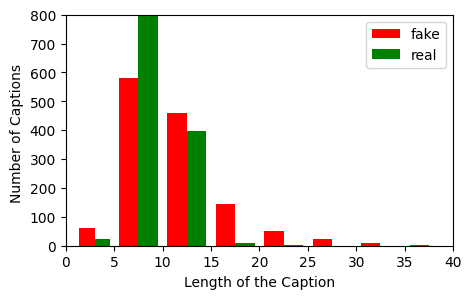

In [41]:
sentence_length_per_class(train_data,'Training')

##Jacard Similarity

In [42]:
## Individual tweets length calculation
def char_length(row):
    return len(row.split())

lables = ['fake','real']
# Count number of unique words in each set

final_list = []

for l in lables:
  label_wise_word_list = []
  word_list = [word.strip() for t in list(train_data[train_data[l]==1].cleaned) for word in t.strip().split()]
  counts = dict()
  for word in word_list:
      counts[word] = counts.get(word,0) + 1
      # sort the dictionary of word list
  ordered = sorted(counts.items(), key= lambda item: item[1], reverse = True)
  print(f"\nClass Name:--> {l} ")

  for k,v in ordered[:400]:
    label_wise_word_list.append(k)

  final_list.append(label_wise_word_list)


Class Name:--> fake 

Class Name:--> real 


In [43]:
def jaccard_similarity(list1, list2):
    s1 = set(list1)
    s2 = set(list2)
    return float(len(s1.intersection(s2)) / len(s1.union(s2)))

In [44]:
jaccard_similarity(final_list[0],final_list[1])

0.26582278481012656

##Scatter Plot

In [ ]:
#!pip install texthero

In [ ]:
#!pip install gensim==4.3.1

Evaluation metrices

In [45]:
'''Evaluation Parameters'''

def print_metrices(true,pred):
    print(confusion_matrix(true,pred))
    print(classification_report(true,pred,target_names=['Fake','Real']))
    print("Accuracy : ",accuracy_score(true,pred))
    print("Precison : ",precision_score(true,pred, average = 'weighted'))
    print("Recall : ",recall_score(true,pred,  average = 'weighted'))
    print("F1 : ",f1_score(true,pred,  average = 'weighted'))

#Callbacks

In [46]:
''' Callbacks'''
import tensorflow.keras as keras
keras.backend.clear_session()
def callbacks_with_garbage(model_name):
  accuracy_threshold = 0.98

  class myCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')>accuracy_threshold):
          print("\nReached %2.2f%% accuracy so we will stop trianing" % (accuracy_threshold*100))
          self.model.stop_training = True

  # Garbage Collector - use it like gc.collect()
  import gc
  # Custom Callback To Include in Callbacks List At Training Time
  class GarbageCollectorCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()


  acc_callback = myCallback()
  gc_callback = GarbageCollectorCallback()
  # Saved the Best Model
  filepath = models_path+f"{model_name}.h5"
  checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=False, mode='max')
  # callback list
  callback_list = [acc_callback, gc_callback, checkpoint]

  return callback_list

In [47]:
''' Callbacks'''
keras.backend.clear_session()
def callbacks_check(model_name):
  accuracy_threshold = 0.98

  class myCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')>accuracy_threshold):
          print("\nReached %2.2f%% accuracy so we will stop trianing" % (accuracy_threshold*100))
          self.model.stop_training = True

  acc_callback = myCallback()
  # Saved the Best Model
  filepath = models_path+f"{model_name}.h5"
  checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=False, mode='max')
  # callback list
  callback_list = [acc_callback, checkpoint]

  return callback_list

In [48]:
from sklearn.utils import compute_class_weight
class_weights = compute_class_weight(
                                        class_weight = "balanced",
                                        classes = np.unique(train_data['enc_label']),
                                        y = train_data['enc_label']
                                    )
weight = {i : class_weights[i] for i in range(2)}
weight

{0: 1.0, 1: 1.0}

#Visual Modality

In [49]:
def visual_models(pretrained_model):
  '''
      Input: Pretrained Models weight
  '''
  base_model = pretrained_model
  base_model.trainable = False
  y = base_model.output
  pool = GlobalAveragePooling2D()(y)
  #flatten = Flatten()(pool)
  output = Dense(1, activation='sigmoid')(pool)
  # this is the model we will train
  img_model = Model(inputs=base_model.input, outputs=output)

  return img_model

In [50]:
from tensorflow. keras.applications import VGG19, VGG16, ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

vgg19 = VGG19(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
vgg16 = VGG16(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
resnet = ResNet50(weights='imagenet', include_top=False,input_shape=(150, 150, 3))

I0000 00:00:1758024553.713002      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758024553.713707      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##VGG19

In [51]:
vgg19_model = visual_models(vgg19)
vgg19_model.compile(loss='binary_crossentropy',
                    optimizer=Adam(),
                    metrics = ["accuracy"])

In [52]:
keras.backend.clear_session()
vgg19_model.fit(x=train_image,
              y=train_data['enc_label'],
              epochs=15,
              batch_size =16,
              validation_data = (valid_image,valid_data['enc_label']),
              verbose = 1,
              class_weight = weight,
              callbacks = callbacks_check('vgg19')
              )

Epoch 1/15


I0000 00:00:1758024572.563349     138 service.cc:148] XLA service 0x7e6d8c04e7a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758024572.564575     138 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1758024572.564595     138 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1758024573.082611     138 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/169 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.4688 - loss: 4.8541

I0000 00:00:1758024578.437771     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7320 - loss: 1.5689
Epoch 1: val_accuracy improved from -inf to 0.91111, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg19.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 29s 125ms/step - accuracy: 0.7327 - loss: 1.5640 - val_accuracy: 0.9111 - val_loss: 0.3477
Epoch 2/15
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9617 - loss: 0.1425
Epoch 2: val_accuracy improved from 0.91111 to 0.94222, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg19.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.9617 - loss: 0.1424 - val_accuracy: 0.9422 - val_loss: 0.1979
Epoch 3/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9791 - loss: 0.0737
Epoch 3: val_accuracy did not improve from 0.94222
169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.9791 - loss: 0.0736 

In [53]:
 # Prediction
from tensorflow.keras.models import load_model

model = load_model(models_path+"vgg19.h5")
pred = model.predict(test_image)
y_pred = (pred>0.5).astype(int)
y_pred

29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step


array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
    

In [54]:
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

[[378  42]
 [  6 474]]
              precision    recall  f1-score   support

        Fake       0.98      0.90      0.94       420
        Real       0.92      0.99      0.95       480

    accuracy                           0.95       900
   macro avg       0.95      0.94      0.95       900
weighted avg       0.95      0.95      0.95       900

Accuracy :  0.9466666666666667
Precison :  0.9492974806201551
Recall :  0.9466666666666667
F1 :  0.9464364922376072


##VGG16

In [55]:
from tensorflow.keras.optimizers import RMSprop

keras.backend.clear_session()
vgg16_model = visual_models(vgg16)
vgg16_model.compile(loss='binary_crossentropy',
                    optimizer=RMSprop(),
                    metrics = ["accuracy"])

In [56]:
vgg16_model.fit(x=train_image,
              y=train_data['enc_label'],
              epochs=15,
              batch_size =16,
              validation_data = (valid_image,valid_data['enc_label']),
              verbose = 1,
              class_weight = weight,
              callbacks = callbacks_check('vgg16')
              )

Epoch 1/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8604 - loss: 0.5199
Epoch 1: val_accuracy improved from -inf to 0.95667, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg16.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - accuracy: 0.8608 - loss: 0.5187 - val_accuracy: 0.9567 - val_loss: 0.2031
Epoch 2/15
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9675 - loss: 0.1359
Epoch 2: val_accuracy improved from 0.95667 to 0.97333, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg16.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.9675 - loss: 0.1355 - val_accuracy: 0.9733 - val_loss: 0.1451
Epoch 3/15
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9787 - loss: 0.0554
Reached 98.00% accuracy so we will stop trianing

Epoch 3: val_accuracy improved from 0.97333 to 0.97444, saving model

In [57]:
 # Prediction
model = load_model(models_path+"vgg16.h5")
pred = model.predict(test_image)
y_pred = (pred>0.5).astype(int)

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step


In [58]:
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

[[398  22]
 [  3 477]]
              precision    recall  f1-score   support

        Fake       0.99      0.95      0.97       420
        Real       0.96      0.99      0.97       480

    accuracy                           0.97       900
   macro avg       0.97      0.97      0.97       900
weighted avg       0.97      0.97      0.97       900

Accuracy :  0.9722222222222222
Precison :  0.9729950341247748
Recall :  0.9722222222222222
F1 :  0.9721703479110861


##ResNet50

In [59]:
keras.backend.clear_session()
resnet_model = visual_models(resnet)
resnet_model.compile(loss='binary_crossentropy',
                    optimizer=RMSprop(),
                    metrics = ["accuracy"])

In [60]:
resnet_model.fit(x=train_image,
              y=train_data['enc_label'],
              epochs=15,
              batch_size =16,
              validation_data = (valid_image,valid_data['enc_label']),
              verbose = 1,
              class_weight = weight,
              callbacks = callbacks_check('resnet')
              )

Epoch 1/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9249 - loss: 0.2089
Epoch 1: val_accuracy improved from -inf to 0.98111, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/resnet.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 30s 105ms/step - accuracy: 0.9251 - loss: 0.2082 - val_accuracy: 0.9811 - val_loss: 0.0630
Epoch 2/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9929 - loss: 0.0241
Reached 98.00% accuracy so we will stop trianing

Epoch 2: val_accuracy improved from 0.98111 to 0.99000, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/resnet.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9929 - loss: 0.0241 - val_accuracy: 0.9900 - val_loss: 0.0400


In [61]:
# Prediction
model = load_model(models_path+"resnet.h5")
pred = model.predict(test_image)
y_pred = (pred>0.3).astype(int)

29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step


In [62]:
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

[[399  21]
 [  0 480]]
              precision    recall  f1-score   support

        Fake       1.00      0.95      0.97       420
        Real       0.96      1.00      0.98       480

    accuracy                           0.98       900
   macro avg       0.98      0.97      0.98       900
weighted avg       0.98      0.98      0.98       900

Accuracy :  0.9766666666666667
Precison :  0.9776447105788423
Recall :  0.9766666666666667
F1 :  0.9766172665255234


##Visual Attention

In [63]:
!pip install visual-attention-tf

In [64]:
from visual_attention import PixelAttention2D , ChannelAttention2D,EfficientChannelAttention2D

In [65]:
def visual_models(pretrained_model):
  '''
      Input: Pretrained Models weight
  '''
  base_model = pretrained_model
  base_model.trainable = False
  y = base_model.layers[-2].output
  #EfficientChannelAttention_cnn = EfficientChannelAttention2D(y.shape[-1])(y)
  attention_cnn = PixelAttention2D(y.shape[-1])(y)
  pool = GlobalAveragePooling2D()(attention_cnn)
  #flatten = Flatten()(att)
  output = Dense(1, activation='sigmoid')(pool)
  # this is the model we will train
  img_model = Model(inputs=base_model.input, outputs=output)

  return img_model

In [66]:
vgg19 = VGG19(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
vgg16 = VGG16(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
resnet = ResNet50(weights='imagenet', include_top=False,input_shape=(150, 150, 3))

## VGG16+PixelAttention

In [67]:
keras.backend.clear_session()
vgg16_att_model = visual_models(vgg16)
vgg16_att_model.compile(loss='binary_crossentropy',
                    optimizer=RMSprop(),
                    metrics = ["accuracy"])

In [68]:
vgg16_att_model.fit(x=train_image,
              y=train_data['enc_label'],
              epochs=10,
              batch_size =16,
              validation_data = (valid_image,valid_data['enc_label']),
              verbose = 1,
              class_weight = weight,
              callbacks = callbacks_check('vgg16-att-channel.weights')
              )

Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8197 - loss: 3.0007
Epoch 1: val_accuracy improved from -inf to 0.92333, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg16-att-channel.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.8200 - loss: 2.9948 - val_accuracy: 0.9233 - val_loss: 1.3012
Epoch 2/10
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9436 - loss: 0.6449
Epoch 2: val_accuracy improved from 0.92333 to 0.94000, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg16-att-channel.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.9436 - loss: 0.6448 - val_accuracy: 0.9400 - val_loss: 0.9738
Epoch 3/10
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9617 - loss: 0.3046
Epoch 3: val_accuracy improved from 0.94000 to 0.95000, saving model to /kagg

In [69]:
vgg16_att_model.save_weights(models_path+'vgg16-att-channel.weights.h5')

In [70]:
 # Prediction
model = vgg16_att_model.load_weights(models_path+"vgg16-att-channel.weights.h5")
pred = vgg16_att_model.predict(test_image)
y_pred = (pred>0.4).astype(int)

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step


In [71]:
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

[[399  21]
 [ 37 443]]
              precision    recall  f1-score   support

        Fake       0.92      0.95      0.93       420
        Real       0.95      0.92      0.94       480

    accuracy                           0.94       900
   macro avg       0.93      0.94      0.94       900
weighted avg       0.94      0.94      0.94       900

Accuracy :  0.9355555555555556
Precison :  0.936259622482337
Recall :  0.9355555555555556
F1 :  0.9356117007233751


## VGG19 + PixelAttention

In [72]:
keras.backend.clear_session()
vgg19_att_model = visual_models(vgg19)
vgg19_att_model.compile(loss='binary_crossentropy',
                    optimizer=RMSprop(),
                    metrics = ["accuracy"])

In [73]:
valid_data

,image_name,Captions,Label,enc_label,cleaned
0,2701.jpg,আবু সাঈদ অনার্স দ্বিতীয় বর্ষের শিক্ষার্থী ছিল…...,fake,0,আবু সাঈদ অনার্স দ্বিতীয় বর্ষের শিক্ষার্থী ছিল…...
1,2702.jpg,উপদেষ্টা বলাম সেনাবাহিনী চরম বাকবিতণ্ডায় লিপ্ত...,fake,0,উপদেষ্টা বলাম সেনাবাহিনী চরম বাকবিতণ্ডায় লিপ্ত...
2,2703.jpg,ভয়াবহ!!! হিজাব না পরার জন্য ইসলামিক র‍্যাডিক্য...,fake,0,ভয়াবহ হিজাব না পরার জন্য ইসলামিক র‍্যাডিক্যাল ...
3,2704.jpg,দুই সমন্বয়কের বিরুদ্ধে ত্রাণের ১২ কোটি টাকা আত...,fake,0,দুই সমন্বয়কের বিরুদ্ধে ত্রাণের ১২ কোটি টাকা আত...
4,2705.jpg,মেটিকিউলাস ডিজাইনের অংশ হিশেবে আমার ছেলের লাশট...,fake,0,মেটিকিউলাস ডিজাইনের অংশ হিশেবে আমার ছেলের লাশট...
...,...,...,...,...,...
895,3596.jpg,সুনামগঞ্জে বন্যায় ব্রিজের নিচ দিয়ে বাড়িঘর ভেসে...,fake,0,সুনামগঞ্জে বন্যায় ব্রিজের নিচ দিয়ে বাড়িঘর ভেসে...
896,3597.jpg,মেসিকে সম্মান জানানোর জন্য মেসির জার্সির হাতায়...,fake,0,মেসিকে সম্মান জানানোর জন্য মেসির জার্সির হাতায়...
897,3598.jpg,পর্তুগীজ ফুটবলার ক্রিস্টিয়ানো রোনালদোর কন্ঠে গ...,fake,0,পর্তুগীজ ফুটবলার ক্রিস্টিয়ানো রোনালদোর কন্ঠে গ...
898,3599.jpg,বাস ভাড়া নির্ধারণী সভায় জ্বালানি সচিবের অফিসে ...,fake,0,বাস ভাড়া নির্ধারণী সভায় জ্বালানি সচিবের অফিসে ...


In [74]:
test_data

,image_name,Captions,Label,enc_label,cleaned
0,3601.jpg,মুরগির নকল ডিম বানানোর ভিডিও !,fake,0,মুরগির নকল ডিম বানানোর ভিডিও
1,3602.jpg,পাকিস্তান আমলে (১৯৬৫ সালের ) এদেশের রেলযোগযোগে...,fake,0,পাকিস্তান আমলে ১৯৬৫ সালের এদেশের রেলযোগযোগের ব...
2,3603.jpg,রাজশাহী বিশ্ববিদ্যালয়ে ভর্তি পরীক্ষায় প্রক্সি ...,fake,0,রাজশাহী বিশ্ববিদ্যালয়ে ভর্তি পরীক্ষায় প্রক্সি ...
3,3604.jpg,সিলেটের চলমান বন্যায় ভাসমান পাতিলের দুইটি বাচ্...,fake,0,সিলেটের চলমান বন্যায় ভাসমান পাতিলের দুইটি বাচ্...
4,3605.jpg,“ মসজিদে এ.সি ব্যবহার একটি সুস্পষ্ট বিদ’আত । আ...,fake,0,“ মসজিদে এসি ব্যবহার একটি সুস্পষ্ট বিদ’আত আর য...
...,...,...,...,...,...
895,4496.jpg,‘মুসলমানরা মানসিকভাবে অসুস্থ ও উন্মাদ ‘,fake,0,‘মুসলমানরা মানসিকভাবে অসুস্থ ও উন্মাদ ‘
896,4497.jpg,"কি দেখছেন , মরুভূমিতে জাহাজ পড়ে আছে ?",fake,0,কি দেখছেন মরুভূমিতে জাহাজ পড়ে আছে
897,4498.jpg,চোখের রোগে ভুগছেন ? অন্ধত্বের ভয় করছেন ? এই বি...,fake,0,চোখের রোগে ভুগছেন অন্ধত্বের ভয় করছেন এই বিপ্লব...
898,4499.jpg,ইউরো ২০২০-তে উয়েফা (ইউরোপীয় ফুটবল অ্যাসোসিয়েশন...,fake,0,ইউরো ২০২০তে উয়েফা ইউরোপীয় ফুটবল অ্যাসোসিয়েশন স...


In [75]:
vgg19_att_model.fit(x=train_image,
              y=train_data['enc_label'],
              epochs=10,
              batch_size =16,
              validation_data = (valid_image,valid_data['enc_label']),
              verbose = 1,
              class_weight = weight,
              callbacks = callbacks_check('vgg19-att-channel.weights')
              )

Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8888 - loss: 2.2171
Epoch 1: val_accuracy improved from -inf to 0.93556, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg19-att-channel.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 120ms/step - accuracy: 0.8890 - loss: 2.2108 - val_accuracy: 0.9356 - val_loss: 1.2631
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9622 - loss: 0.3934
Epoch 2: val_accuracy improved from 0.93556 to 0.96222, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg19-att-channel.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.9622 - loss: 0.3935 - val_accuracy: 0.9622 - val_loss: 0.7882
Epoch 3/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9768 - loss: 0.2571
Epoch 3: val_accuracy did not improve from 0.96222
169/169 ━━━━━━━━━━━━━━━━━

In [76]:
vgg19_att_model.save_weights(models_path+'vgg19-att-channel.weights.h5')

In [77]:
 # Prediction
model = vgg19_att_model.load_weights(models_path+"vgg19-att-channel.weights.h5")
pred = vgg19_att_model.predict(test_image)
y_pred = (pred>0.4).astype(int)

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step


In [78]:
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

[[382  38]
 [ 13 467]]
              precision    recall  f1-score   support

        Fake       0.97      0.91      0.94       420
        Real       0.92      0.97      0.95       480

    accuracy                           0.94       900
   macro avg       0.95      0.94      0.94       900
weighted avg       0.94      0.94      0.94       900

Accuracy :  0.9433333333333334
Precison :  0.9445093370096503
Recall :  0.9433333333333334
F1 :  0.9431833328143003


## ResNet50 + PixelAttention

In [79]:
keras.backend.clear_session()
resnet_att_model = visual_models(resnet)
resnet_att_model.compile(loss='binary_crossentropy',
                    optimizer=Adam(),
                    metrics = ["accuracy"])

In [80]:
resnet_att_model.fit(x=train_image,
              y=train_data['enc_label'],
              epochs=10,
              batch_size =16,
              validation_data = (valid_image,valid_data['enc_label']),
              verbose = 1,
              class_weight = weight,
              callbacks = callbacks_check('resnet-att-channel.weights')
              )

Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9019 - loss: 0.4701
Epoch 1: val_accuracy improved from -inf to 0.98333, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/resnet-att-channel.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 30s 103ms/step - accuracy: 0.9022 - loss: 0.4686 - val_accuracy: 0.9833 - val_loss: 0.0902
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9862 - loss: 0.0430
Reached 98.00% accuracy so we will stop trianing

Epoch 2: val_accuracy did not improve from 0.98333
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.9862 - loss: 0.0429 - val_accuracy: 0.9756 - val_loss: 0.1485


In [81]:
resnet_att_model.save_weights(models_path+'resnet-att-channel.weights.h5')

In [82]:
 # Prediction
model = resnet_att_model.load_weights(models_path+"resnet-att-channel.weights.h5")
pred = resnet_att_model.predict(test_image)
y_pred = (pred>0.5).astype(int)

29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 203ms/step


In [83]:
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

[[366  54]
 [  1 479]]
              precision    recall  f1-score   support

        Fake       1.00      0.87      0.93       420
        Real       0.90      1.00      0.95       480

    accuracy                           0.94       900
   macro avg       0.95      0.93      0.94       900
weighted avg       0.94      0.94      0.94       900

Accuracy :  0.9388888888888889
Precison :  0.9446946575942389
Recall :  0.9388888888888889
F1 :  0.9384298068355763


#Textual Models

##Keras Tokenizer

In [84]:
!pip install transformers

In [85]:
''' Tokenizer '''
from tensorflow.keras.preprocessing.text import Tokenizer

def text_tokenizer(train_data,test_data,vocabulary,max_len,sample_text_num):

  tokenizer = Tokenizer(num_words = vocabulary ,filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n-',
                        split=' ', char_level=False, oov_token='<oov>', document_count=0)
  tokenizer.fit_on_texts(train_data['Captions'])
  word_index = tokenizer.word_index
  vocab_size = len(word_index)+1

  # Training Sequences
  train_sequences = tokenizer.texts_to_sequences(train_data['Captions'])
  train_pad_sequences =  keras.preprocessing.sequence.pad_sequences(train_sequences, value=0.0, padding='post', maxlen= max_len)


  # Validation Sequences
  valid_sequences = tokenizer.texts_to_sequences(valid_data['Captions'])
  valid_pad_sequences =  keras.preprocessing.sequence.pad_sequences(valid_sequences, value=0.0, padding='post', maxlen= max_len)


  # Test Sequences
  test_sequences = tokenizer.texts_to_sequences(test_data['Captions'])
  test_pad_sequences =  keras.preprocessing.sequence.pad_sequences(test_sequences, value=0.0, padding='post', maxlen= max_len)


  print(color.BOLD+"\n\t\t\t====== Encoded Sequences ======"+color.END,"\n")
  print(train_data.Captions[sample_text_num],"\n",train_sequences[sample_text_num])
  print(color.BOLD+"\n\t\t\t====== Paded Sequences ======\n"+color.END,"\n",train_pad_sequences[sample_text_num])

  return train_pad_sequences, valid_pad_sequences, test_pad_sequences, vocab_size, word_index


vocabulary = 15000
max_len = 50
sample_text_num = 10

## Call Tokenizer
train_pad_sequences, valid_pad_sequences, test_pad_sequences, vocab_size, word_index =  text_tokenizer(train_data,test_data,
                                                                      vocabulary,max_len,sample_text_num)

print("Number of Train Sequences :" ,train_pad_sequences.shape)
print("Number of Test Sequences :" ,test_pad_sequences.shape)
print("Vocabulary Size: ",vocab_size)


			====== Encoded Sequences ====== 

রাজশাহী বিশ্ববিদ্যালয়ে পবিত্র কোরআন পোড়ানোর ঘটনায় ফেরদৌস ফরিদ গ্রেফতার হয়েছে। তার উদ্দেশ্য ছিলো হিন্দুবিদ্বেষী সাম্প্রদায়িক দাঙ্গা সৃষ্টি করা ও ভারতবিদ্বেষী রাজনীতিকে উস্কে দেয়া। শোনা যায় ঘটনা ঘটানোর পর নিজেকে আড়াল করতে সে মাথার চুল এবং দাড়ি কেটে ফেলে!! আমার ভেতর একটা প্রশ্নের উদ্রেক হয়েছে। এই ফরিদের নিজের কি পবিত্র কোরআন শরীফে বিশ্বাস আছে ? যদি তা থাকতো তাহলে কি সে কেবল দাঙ্গা বাঁধাতে কোরআন পোড়াতে পারতো ? জামায়াত শিবির কি ইসলাম ধর্মে বিশ্বাস করে নাকি ধর্মকে কেবলই রাজনৈতিক ফায়দা হাসিলের উপায় হিসেবে ব্যবহার করে ? 
 [909, 304, 280, 208, 3566, 178, 3567, 3568, 303, 641, 45, 1154, 1155, 3569, 1527, 2146, 756, 15, 3, 3570, 3571, 3572, 3573, 3574, 234, 479, 3575, 12, 1156, 3576, 9, 278, 2147, 3577, 43, 3578, 1157, 480, 128, 2148, 305, 1528, 3579, 641, 11, 3580, 375, 30, 280, 208, 2149, 1158, 127, 376, 642, 2150, 549, 30, 278, 1159, 2146, 3581, 208, 3582, 3583, 427, 481, 30, 74, 1529, 1158, 5, 905, 3584, 3585, 142, 3586, 3587, 3588, 108, 334, 5]

			=

##BiLSTM+CNN

In [86]:
##### LSTM-CNN Model ####
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

lc_text_inputs = Input(shape=(max_len,))
lc_embedding_layer = Embedding(vocab_size,64)(lc_text_inputs)
LSTM_Layer = Bidirectional(LSTM(32,return_sequences=True))(lc_embedding_layer)
lc_conv1 = Conv1D(32,2,activation='relu')(LSTM_Layer)
lc_pool1 = MaxPooling1D(2)(lc_conv1)
lc_flat = Flatten()(lc_pool1)
lc_dense_layer_1 = Dense(1, activation='sigmoid')(lc_flat)
cnn_lstm_model = Model(inputs=lc_text_inputs, outputs=lc_dense_layer_1)

In [87]:
keras.backend.clear_session()
cnn_lstm_model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])


cnn_lstm_model.fit(train_pad_sequences,
    train_data['enc_label'],
    epochs=20,
    batch_size =32,
    validation_data = (valid_pad_sequences,valid_data['enc_label']),
    verbose = 1,
    class_weight = weight,
    callbacks = callbacks_check('lstm-cnn'))

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5602 - loss: 0.6817
Epoch 1: val_accuracy improved from -inf to 0.75333, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/lstm-cnn.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5609 - loss: 0.6813 - val_accuracy: 0.7533 - val_loss: 0.4963
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8986 - loss: 0.2849
Epoch 2: val_accuracy improved from 0.75333 to 0.80222, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/lstm-cnn.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8987 - loss: 0.2844 - val_accuracy: 0.8022 - val_loss: 0.4910
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9938 - loss: 0.0271
Reached 98.00% accuracy so we will stop trianing

Epoch 3: val_accuracy improved from 0.80222 to 0.80333, saving model to /kagg

In [88]:
 # Prediction
model = load_model(models_path+"lstm-cnn.h5")
pred = model.predict(test_pad_sequences)
y_pred = (pred>0.5).astype(int)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
[[343  77]
 [152 328]]
              precision    recall  f1-score   support

        Fake       0.69      0.82      0.75       420
        Real       0.81      0.68      0.74       480

    accuracy                           0.75       900
   macro avg       0.75      0.75      0.75       900
weighted avg       0.76      0.75      0.75       900

Accuracy :  0.7455555555555555
Precison :  0.7553011597456043
Recall :  0.7455555555555555
F1 :  0.7452020623012565


##LSTM+ATT

In [89]:
def create_lstm_attention_model (max_len,vocab_size,embedding_dimension):

  class Attention(tf.keras.Model):
      def __init__(self, units):
          super(Attention, self).__init__()
          self.W1 = tf.keras.layers.Dense(units)
          self.W2 = tf.keras.layers.Dense(units)
          self.V = tf.keras.layers.Dense(1)

      def call(self, features, hidden):
          # hidden shape == (batch_size, hidden size)
          # hidden_with_time_axis shape == (batch_size, 1, hidden size)
          # we are doing this to perform addition to calculate the score
          hidden_with_time_axis = tf.expand_dims(hidden, 1)

          # score shape == (batch_size, max_length, 1)
          # we get 1 at the last axis because we are applying score to self.V
          # the shape of the tensor before applying self.V is (batch_size, max_length, units)
          score = tf.nn.tanh(
              self.W1(features) + self.W2(hidden_with_time_axis))
          # attention_weights shape == (batch_size, max_length, 1)
          attention_weights = tf.nn.softmax(self.V(score), axis=1)

          # context_vector shape after sum == (batch_size, hidden_size)
          context_vector = attention_weights * features
          context_vector = tf.reduce_sum(context_vector, axis=1)
          return context_vector, attention_weights

  sequence_input = Input(shape=(max_len,), dtype="int32")
  embedded_sequences = Embedding(vocab_size, embedding_dimension)(sequence_input)
  #lstm = Bidirectional(LSTM(128, return_sequences = True), name="bi_lstm_0")(embedded_sequences)
  # Getting our LSTM outputs
  (lstm, forward_h, forward_c, backward_h, backward_c) = Bidirectional(LSTM(32, return_sequences=True, return_state=True), name="bi_lstm_1")(embedded_sequences)

  state_h = Concatenate()([forward_h, backward_h])
  state_c = Concatenate()([forward_c, backward_c])
  context_vector, attention_weights = Attention(20)(lstm, state_h)
  #dense1 = Dense(20, activation="relu")(context_vector)
  #dropout = Dropout(0.01)(dense1)
  output = Dense(1, activation="sigmoid")(context_vector)

  lstm_attention_model = Model(inputs=sequence_input, outputs=output)

  return lstm_attention_model


In [90]:
filepath = models_path + 'lstm_att.weights.h5'
checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )

In [91]:
import tensorflow as tf
from tensorflow.keras.layers import Concatenate


maximum_length = 50
vocabulary_size = vocab_size
embedding_dimension = 64
keras.backend.clear_session()
####

model = create_lstm_attention_model (maximum_length,vocabulary_size,embedding_dimension)
model.compile(loss='binary_crossentropy',
              optimizer= Adam(),
              metrics=['accuracy'])

model.fit(train_pad_sequences,train_data['enc_label'],
                    batch_size=32,
                    epochs=10,
                    validation_data = (valid_pad_sequences, valid_data['enc_label']),
                    verbose =1,
                    callbacks = [checkpoint] )

Epoch 1/10
80/85 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5272 - loss: 0.6925
Epoch 1: val_accuracy improved from -inf to 0.73000, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/lstm_att.weights.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5311 - loss: 0.6919 - val_accuracy: 0.7300 - val_loss: 0.6170
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8583 - loss: 0.4145
Epoch 2: val_accuracy improved from 0.73000 to 0.76667, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/lstm_att.weights.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8586 - loss: 0.4136 - val_accuracy: 0.7667 - val_loss: 0.4587
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9742 - loss: 0.0960
Epoch 3: val_accuracy improved from 0.76667 to 0.77556, saving model to /kaggle/working/ndd-news-detection-data

In [92]:
model = create_lstm_attention_model (maximum_length,vocabulary_size,embedding_dimension)
model.load_weights(models_path + 'lstm_att.weights.h5')
y_pred = (model.predict(test_pad_sequences)>0.5).astype(int)
print_metrices(y_true,y_pred)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
[[354  66]
 [150 330]]
              precision    recall  f1-score   support

        Fake       0.70      0.84      0.77       420
        Real       0.83      0.69      0.75       480

    accuracy                           0.76       900
   macro avg       0.77      0.77      0.76       900
weighted avg       0.77      0.76      0.76       900

Accuracy :  0.76
Precison :  0.7722222222222223
Recall :  0.76
F1 :  0.7594022415940225


##Transformers

In [93]:
############################## Sentence Encoding for Transformers

def bert_encode(data,maximum_length,tokenizer) :
  input_ids = []
  attention_masks = []


  for i in range(len(data.Captions)):
      encoded = tokenizer.encode_plus(

        data.Captions[i],
        add_special_tokens=True,
        max_length=maximum_length,
        pad_to_max_length=True,
        truncation=True,
        return_attention_mask=True,

      )

      input_ids.append(encoded['input_ids'])
      attention_masks.append(encoded['attention_mask'])
  return np.array(input_ids),np.array(attention_masks)

In [94]:
from tensorflow.keras.layers import Input, Dense, Dropout, Layer

class BertLayer(Layer):
    def __init__(self, bert_model, **kwargs):
        super(BertLayer, self).__init__(**kwargs)
        self.bert = bert_model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state  # same as outputs[0]

def create_model(bert_model, max_len):
    input_ids = Input(shape=(max_len,), dtype=tf.int32, name='input_ids')
    attention_mask = Input(shape=(max_len,), dtype=tf.int32, name='attention_mask')

    bert_output = BertLayer(bert_model)([input_ids, attention_mask])
    cls_token = bert_output[:, 0, :]  # CLS token
    dropout = Dropout(0.1)(cls_token)
    output = Dense(1, activation='sigmoid')(dropout)

    model = Model(inputs=[input_ids, attention_mask], outputs=output)
    return model

###Bangla-BERT

In [95]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('sagorsarker/bangla-bert-base')

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

In [96]:
def bert_encode(data, maximum_length, tokenizer):
    input_ids = []
    attention_masks = []

    for sentence in data:
        encoded = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=maximum_length,
            padding='max_length',         # <- replace pad_to_max_length
            truncation=True,              # <- ensure it doesn’t exceed max_length
            return_attention_mask=True,
            return_tensors='np'           # return as numpy-compatible
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])

    return np.array(input_ids), np.array(attention_masks)


In [97]:
train_input_ids,train_attention_masks = bert_encode(train_data,50,tokenizer)
valid_input_ids,valid_attention_masks = bert_encode(valid_data,50,tokenizer)
test_input_ids,test_attention_masks = bert_encode(test_data,50,tokenizer)

In [98]:
!pip install tf-keras

In [99]:
from transformers import TFBertModel
bert_model = TFBertModel.from_pretrained('sagorsarker/bangla-bert-base')

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

In [100]:
### Checkpoint
filepath = models_path + 'bangla-bert-1.weights.h5'
checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True, save_weights_only=True, mode='max' )


In [101]:
keras.backend.clear_session()
# 3e-4, 1e-4, 5e-5, 3e-5,1e-5
model = create_model(bert_model, 50)
model.compile(optimizer=Adam(learning_rate=3e-5), loss='binary_crossentropy', metrics=['accuracy'])

In [102]:
# Encode input data correctly (adjust 'text' if needed)
train_input_ids, train_attention_masks = bert_encode(train_data['Captions'], 50, tokenizer)
valid_input_ids, valid_attention_masks = bert_encode(valid_data['Captions'], 50, tokenizer)

# Check and print data shapes
print("Train input_ids:", len(train_input_ids))
print("Train attention_masks:", len(train_attention_masks))
print("Train labels:", len(train_data['enc_label']))
print("Valid input_ids:", len(valid_input_ids))
print("Valid attention_masks:", len(valid_attention_masks))
print("Valid labels:", len(valid_data['enc_label']))

# Assert shapes are consistent
assert len(train_input_ids) == len(train_attention_masks) == len(train_data['enc_label']), "Mismatch in training data"
assert len(valid_input_ids) == len(valid_attention_masks) == len(valid_data['enc_label']), "Mismatch in validation data"

# Train the model
model.fit(
    [train_input_ids, train_attention_masks],
    train_data['enc_label'],
    validation_data=([valid_input_ids, valid_attention_masks], valid_data['enc_label']),
    epochs=6,
    batch_size=16,
    callbacks=[checkpoint]
    # class_weight=weight  # Uncomment if you're using class weighting
)

Train input_ids: 2700
Train attention_masks: 2700
Train labels: 2700
Valid input_ids: 900
Valid attention_masks: 900
Valid labels: 900
Epoch 1/6


W0000 00:00:1758025619.819438     137 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5690 - loss: 0.7572

W0000 00:00:1758025632.126145     140 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5693 - loss: 0.7569

W0000 00:00:1758025639.022269     140 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758025643.757972     140 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert



Epoch 1: val_accuracy improved from -inf to 0.61889, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/bangla-bert-1.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 42s 130ms/step - accuracy: 0.5696 - loss: 0.7566 - val_accuracy: 0.6189 - val_loss: 0.7237
Epoch 2/6
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6661 - loss: 0.6293
Epoch 2: val_accuracy improved from 0.61889 to 0.66333, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/bangla-bert-1.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.6665 - loss: 0.6288 - val_accuracy: 0.6633 - val_loss: 0.6415
Epoch 3/6
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7624 - loss: 0.5159
Epoch 3: val_accuracy improved from 0.66333 to 0.70444, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake N

In [ ]:
#bangla-bert ---> 1e-5
#bangla-bert ---->3e-5

In [103]:
def bert_encode(data, max_len, tokenizer):
    input_ids = []
    attention_masks = []
    
    for sentence in data['Captions'].values:  # <-- Make sure to use .values to loop over all text
        encoded = tokenizer.encode_plus(
            sentence,
            max_length=max_len,
            padding='max_length',     # padding=True is now deprecated in many tokenizers
            truncation=True,
            return_attention_mask=True,
            return_tensors='np'       # or 'pt' if using PyTorch
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])

    return np.array(input_ids), np.array(attention_masks)


In [104]:
test_input_ids, test_attention_masks = bert_encode(test_data, 50, tokenizer)

y_pred = (model.predict([test_input_ids, test_attention_masks]) > 0.5).astype(int).flatten()
y_true = test_data['enc_label'].values
print_metrices(y_true, y_pred)

W0000 00:00:1758025716.635006     140 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

W0000 00:00:1758025724.399613     137 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 273ms/step
[[281 139]
 [ 40 440]]
              precision    recall  f1-score   support

        Fake       0.88      0.67      0.76       420
        Real       0.76      0.92      0.83       480

    accuracy                           0.80       900
   macro avg       0.82      0.79      0.79       900
weighted avg       0.81      0.80      0.80       900

Accuracy :  0.8011111111111111
Precison :  0.8138115453112306
Recall :  0.8011111111111111
F1 :  0.7971215173839298


###M-BERT

In [105]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [106]:
print(len(train_data), len(valid_data), len(test_data))

2700 900 900


In [107]:
train_input_ids,train_attention_masks = bert_encode(train_data,50,tokenizer)
valid_input_ids,valid_attention_masks = bert_encode(valid_data,50,tokenizer)
test_input_ids,test_attention_masks = bert_encode(test_data,50,tokenizer)

In [108]:
from transformers import TFBertModel
bert_model = TFBertModel.from_pretrained('bert-base-multilingual-cased')

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

In [109]:
### Checkpoint
filepath = models_path + 'm-bert.weights.h5'
checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )


In [110]:
keras.backend.clear_session()
model = create_model(bert_model,50)
model.compile(optimizer=Adam(learning_rate=3e-5), loss='binary_crossentropy', metrics=['accuracy'])
#model.summary()

In [111]:

model.fit([train_input_ids,train_attention_masks],
                    train_data['enc_label'],
                    validation_data = ([valid_input_ids,valid_attention_masks], valid_data['enc_label']),
                    epochs=6,
                    batch_size=16,
                    callbacks = [checkpoint]
                    # class_weight = weight
          )

Epoch 1/6


W0000 00:00:1758025797.436376     140 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5023 - loss: 0.7354

W0000 00:00:1758025809.012122     140 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5023 - loss: 0.7353

W0000 00:00:1758025815.664234     139 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758025820.240489     137 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert



Epoch 1: val_accuracy improved from -inf to 0.47889, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/m-bert.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 40s 125ms/step - accuracy: 0.5024 - loss: 0.7352 - val_accuracy: 0.4789 - val_loss: 0.7026
Epoch 2/6
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5603 - loss: 0.6671
Epoch 2: val_accuracy improved from 0.47889 to 0.53556, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/m-bert.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.5607 - loss: 0.6669 - val_accuracy: 0.5356 - val_loss: 0.6682
Epoch 3/6
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6582 - loss: 0.6203
Epoch 3: val_accuracy improved from 0.53556 to 0.62667, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/m-b

In [112]:
model2 = create_model(bert_model,50)
model2.load_weights(models_path+"m-bert.weights.h5")
y_pred = (model2.predict([test_input_ids,test_attention_masks])>0.5).astype(int)
#y_pred = np.argmax(pred,axis=1)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

W0000 00:00:1758026089.553159     137 assert_op.cc:38] Ignoring Assert operator functional_1_1/bert_layer_1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

W0000 00:00:1758026096.926092     140 assert_op.cc:38] Ignoring Assert operator functional_1_1/bert_layer_1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 275ms/step
[[198 222]
 [  4 476]]
              precision    recall  f1-score   support

        Fake       0.98      0.47      0.64       420
        Real       0.68      0.99      0.81       480

    accuracy                           0.75       900
   macro avg       0.83      0.73      0.72       900
weighted avg       0.82      0.75      0.73       900

Accuracy :  0.7488888888888889
Precison :  0.821131568744267
Recall :  0.7488888888888889
F1 :  0.7281191257367565


###XLM-R

In [113]:
!pip install sentencepiece

In [114]:
from transformers import XLMRobertaTokenizer
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

In [115]:
train_input_ids,train_attention_masks = bert_encode(train_data,50,tokenizer)
val_input_ids,val_attention_masks = bert_encode(valid_data,50,tokenizer)
test_input_ids,test_attention_masks = bert_encode(test_data,50,tokenizer)

In [116]:
from transformers import TFXLMRobertaModel
xlm_model = TFXLMRobertaModel.from_pretrained("jplu/tf-xlm-roberta-base")

config.json:   0%|          | 0.00/512 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

Some layers from the model checkpoint at jplu/tf-xlm-roberta-base were not used when initializing TFXLMRobertaModel: ['lm_head']
- This IS expected if you are initializing TFXLMRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFXLMRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFXLMRobertaModel were initialized from the model checkpoint at jplu/tf-xlm-roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFXLMRobertaModel for predictions without further training.


In [117]:
### Checkpoint
filepath = models_path + 'xlm-r.weights.h5'
checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )

In [118]:
keras.backend.clear_session()
model = create_model(xlm_model,50)
model.compile(optimizer=Adam(learning_rate=3e-5), loss='binary_crossentropy', metrics=['accuracy'])
#model.compile(Adam(lr=1e-5), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_layer          │ (None, 50, 768)   │          0 │ input_ids[0][0],  │
│ (BertLayer)         │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 768)       │          0 │ bert_layer[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 768)       │          0 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        769 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
model.fit([train_input_ids,train_attention_masks],
                    train_data['enc_label'],
                    validation_data = ([val_input_ids,val_attention_masks],valid_data['enc_label']),
                    epochs=6,
                    batch_size=16,
                    callbacks = [checkpoint])

Epoch 1/6


W0000 00:00:1758026202.463308     140 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tfxlm_roberta_model/roberta/embeddings/assert_less/Assert/Assert


168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4747 - loss: 0.7751

W0000 00:00:1758026214.383497     137 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tfxlm_roberta_model/roberta/embeddings/assert_less/Assert/Assert


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4749 - loss: 0.7750

W0000 00:00:1758026221.642681     137 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tfxlm_roberta_model/roberta/embeddings/assert_less/Assert/Assert
W0000 00:00:1758026227.804804     139 assert_op.cc:38] Ignoring Assert operator functional_1/bert_layer_1/tfxlm_roberta_model/roberta/embeddings/assert_less/Assert/Assert



Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/xlm-r.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 44s 138ms/step - accuracy: 0.4750 - loss: 0.7749 - val_accuracy: 0.5000 - val_loss: 0.7264
Epoch 2/6
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5054 - loss: 0.7238
Epoch 2: val_accuracy did not improve from 0.50000
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5054 - loss: 0.7237 - val_accuracy: 0.5000 - val_loss: 0.7098
Epoch 3/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4966 - loss: 0.7133
Epoch 3: val_accuracy improved from 0.50000 to 0.50111, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/xlm-r.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.4966 - loss: 0.7133 - val_accuracy: 0.5011 - val_loss: 0.7018
Epoch 4/6
169/169 ━

In [120]:
model1 = create_model(xlm_model,50)
model1.load_weights(models_path+"xlm-r.weights.h5")

y_pred = (model1.predict([test_input_ids,test_attention_masks])>0.5).astype(int)
#y_pred = np.argmax(pred,axis=1)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

W0000 00:00:1758026292.316840     139 assert_op.cc:38] Ignoring Assert operator functional_1_1/bert_layer_1_1/tfxlm_roberta_model/roberta/embeddings/assert_less/Assert/Assert


28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

W0000 00:00:1758026302.765319     140 assert_op.cc:38] Ignoring Assert operator functional_1_1/bert_layer_1_1/tfxlm_roberta_model/roberta/embeddings/assert_less/Assert/Assert


29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 346ms/step
[[418   2]
 [480   0]]
              precision    recall  f1-score   support

        Fake       0.47      1.00      0.63       420
        Real       0.00      0.00      0.00       480

    accuracy                           0.46       900
   macro avg       0.23      0.50      0.32       900
weighted avg       0.22      0.46      0.30       900

Accuracy :  0.46444444444444444
Precison :  0.2172234595397179
Recall :  0.46444444444444444
F1 :  0.2960040465351543


#Multimodal Models

In [121]:
from tensorflow.keras.layers import Input, Dense, Dropout, Layer

class BertLayer(Layer):
    def __init__(self, bert_model, **kwargs):
        super(BertLayer, self).__init__(**kwargs)
        self.bert = bert_model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state  # same as outputs[0]

def create_model(bert_model, max_len):
    print('multimodal invoked')
    input_ids = Input(shape=(max_len,), dtype=tf.int32, name='input_ids')
    attention_mask = Input(shape=(max_len,), dtype=tf.int32, name='attention_mask')

    bert_output = BertLayer(bert_model)([input_ids, attention_mask])
    cls_token = bert_output[:, 0, :]  # CLS token
    dropout = Dropout(0.1)(cls_token)
    output = Dense(10, activation='relu')(dropout)

    model = Model(inputs=[input_ids, attention_mask], outputs=output)
    return model

In [122]:
from transformers import BertTokenizer, TFBertModel
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')  # or your specific model

##VGG16 + Bangla-BERT

In [123]:
## VGG16
base_model = VGG19(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
base_model.trainable = False
y = base_model.output
pool = GlobalAveragePooling2D()(y)
#flatten = Flatten()(pool)
fc_layer_v = Dense(10, activation='relu')(pool)
#output = Dense(1, activation='sigmoid')(pool)
  # this is the model we will train
img_model = Model(inputs=base_model.input, outputs=fc_layer_v)


# text model
text_model = create_model(bert_model,50)

# Fusion
con_layer = keras.layers.concatenate([img_model.output, text_model.output])
final_dense = Dense(4, activation="relu")(con_layer)
dropout = Dropout(0.1)(final_dense)
out = Dense(1,activation='sigmoid')(dropout)
com_model = Model(inputs = [img_model.input, text_model.input], outputs=out)
#com_model.summary()

multimodal invoked


In [124]:
### Checkpoint
filepath = models_path + 'b-bert+vgg19.weights.h5'
checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )


In [125]:
keras.backend.clear_session()
model = com_model
model.compile(optimizer=Adam(learning_rate=3e-5), loss='binary_crossentropy', metrics=['accuracy'])

In [126]:
print(len(train_image))

2700


In [127]:
train_input_ids,train_attention_masks = bert_encode(train_data,50,tokenizer)
val_input_ids,val_attention_masks = bert_encode(valid_data,50,tokenizer)
test_input_ids,test_attention_masks = bert_encode(test_data,50,tokenizer)

In [128]:
print(train_input_ids)

[[  101   941 22335 ...     0     0     0]
 [  101 24288 26145 ... 22875 33664   102]
 [  101   976 16431 ... 61607 11128   102]
 ...
 [  101   955 58354 ...     0     0     0]
 [  101 88324 11199 ...     0     0     0]
 [  101 28777 36715 ...     0     0     0]]


In [129]:
model.fit([train_image,train_input_ids,train_attention_masks],
                    train_data['enc_label'],
                    validation_data = ([valid_image, valid_input_ids,valid_attention_masks], valid_data['enc_label']),
                    epochs=6,
                    batch_size=16,
                    callbacks = [checkpoint],
                    #class_weight = weight
          )

Epoch 1/6


W0000 00:00:1758026372.675911     140 assert_op.cc:38] Ignoring Assert operator functional_4_1/bert_layer_2_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6555 - loss: 0.6317

W0000 00:00:1758026398.305485     138 assert_op.cc:38] Ignoring Assert operator functional_4_1/bert_layer_2_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6559 - loss: 0.6312
Epoch 1: val_accuracy improved from -inf to 0.77556, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/b-bert+vgg19.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 65s 246ms/step - accuracy: 0.6563 - loss: 0.6308 - val_accuracy: 0.7756 - val_loss: 0.4674
Epoch 2/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8193 - loss: 0.4295
Epoch 2: val_accuracy improved from 0.77556 to 0.85444, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/b-bert+vgg19.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 28s 167ms/step - accuracy: 0.8194 - loss: 0.4293 - val_accuracy: 0.8544 - val_loss: 0.3505
Epoch 3/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8544 - loss: 0.3384
Epoch 3: val_accuracy improved from 0.85444 to 0.88556, saving model to /kaggle/working/ndd-news

In [130]:
y_pred = (model.predict([test_image,test_input_ids,test_attention_masks])>0.5).astype(int)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 428ms/step
[[363  57]
 [ 12 468]]
              precision    recall  f1-score   support

        Fake       0.97      0.86      0.91       420
        Real       0.89      0.97      0.93       480

    accuracy                           0.92       900
   macro avg       0.93      0.92      0.92       900
weighted avg       0.93      0.92      0.92       900

Accuracy :  0.9233333333333333
Precison :  0.9271619047619047
Recall :  0.9233333333333333
F1 :  0.9228799399230262


##VGG16 (Attention) + Bangla-BERT

In [131]:
from visual_attention import PixelAttention2D, EfficientChannelAttention2D
## VGG16 or VGG19
base_model = VGG19(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
base_model.trainable = False
y = base_model.layers[-2].output
  #EfficientChannelAttention_cnn = EfficientChannelAttention2D(y.shape[-1])(y)
attention_cnn = PixelAttention2D(y.shape[-1])(y)
pool = GlobalAveragePooling2D()(attention_cnn)
fc_layer_v = Dense(10, activation='relu')(pool)
  # this is the model we will train
img_model = Model(inputs=base_model.input, outputs=fc_layer_v)


# text model
text_model = create_model(bert_model,50)

# Fusion
con_layer = keras.layers.concatenate([img_model.output, text_model.output])
final_dense = Dense(4, activation="relu")(con_layer)
dropout = Dropout(0.1)(final_dense)
out = Dense(1,activation='sigmoid')(dropout)
com_model = Model(inputs = [img_model.input, text_model.input], outputs=out)
#com_model.summary()

multimodal invoked


In [132]:
### Checkpoint
filepath = models_path + 'b-bert+vgg19-att.weights.h5'
checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )


In [133]:
keras.backend.clear_session()
model = com_model
model.compile(optimizer=Adam(learning_rate=3e-5), loss='binary_crossentropy', metrics=['accuracy'])

In [134]:
model.fit([train_image,train_input_ids,train_attention_masks],
                    train_data['enc_label'],
                    validation_data = ([valid_image, valid_input_ids,valid_attention_masks], valid_data['enc_label']),
                    epochs=10,
                    batch_size=16,
                    callbacks = [checkpoint],
          )

Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.5270 - loss: 2.2894
Epoch 1: val_accuracy improved from -inf to 0.70333, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/b-bert+vgg19-att.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 66s 248ms/step - accuracy: 0.5274 - loss: 2.2841 - val_accuracy: 0.7033 - val_loss: 0.7977
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7042 - loss: 0.7862
Epoch 2: val_accuracy improved from 0.70333 to 0.75889, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/b-bert+vgg19-att.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 28s 165ms/step - accuracy: 0.7043 - loss: 0.7858 - val_accuracy: 0.7589 - val_loss: 0.6644
Epoch 3/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7797 - loss: 0.5551
Epoch 3: val_accuracy did not improve from 0.75889
169/169 ━━━━━━━━━━━━━━━━

In [135]:
y_pred = (model.predict([test_image,test_input_ids,test_attention_masks])>0.50).astype(int)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 443ms/step
[[320 100]
 [ 42 438]]
              precision    recall  f1-score   support

        Fake       0.88      0.76      0.82       420
        Real       0.81      0.91      0.86       480

    accuracy                           0.84       900
   macro avg       0.85      0.84      0.84       900
weighted avg       0.85      0.84      0.84       900

Accuracy :  0.8422222222222222
Precison :  0.8467237637522506
Recall :  0.8422222222222222
F1 :  0.8408657799841556


##VGG19 + XLM-R

In [136]:
## VGG16
base_model = VGG16(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
base_model.trainable = False
y = base_model.output
pool = GlobalAveragePooling2D()(y)
#flatten = Flatten()(pool)
fc_layer_v = Dense(10, activation='relu')(pool)
  # this is the model we will train
img_model = Model(inputs=base_model.input, outputs=fc_layer_v)


# text model
text_model = create_model(xlm_model,50)

# Fusion
con_layer = keras.layers.concatenate([img_model.output, text_model.output])
final_dense = Dense(4, activation="relu")(con_layer)
dropout = Dropout(0.1)(final_dense)
out = Dense(1,activation='sigmoid')(dropout)
com_model = Model(inputs = [img_model.input, text_model.input], outputs=out)

multimodal invoked


In [137]:
### Checkpoint
filepath = models_path + 'xlmr+vgg16.weights.h5'
checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )


In [138]:
keras.backend.clear_session()
model = com_model
model.compile(optimizer=Adam(learning_rate=3e-5), loss='binary_crossentropy', metrics=['accuracy'])
#model.summary()

In [139]:
model.fit([train_image,train_input_ids,train_attention_masks],
                    train_data['enc_label'],
                    validation_data = ([valid_image, val_input_ids,val_attention_masks], valid_data['enc_label']),
                    epochs=5,
                    batch_size=16,
                    callbacks = [checkpoint],
                    # class_weight = weight
          )

Epoch 1/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5811 - loss: 0.8243
Epoch 1: val_accuracy improved from -inf to 0.69667, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/xlmr+vgg16.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 63s 247ms/step - accuracy: 0.5813 - loss: 0.8240 - val_accuracy: 0.6967 - val_loss: 0.6582
Epoch 2/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7060 - loss: 0.6499
Epoch 2: val_accuracy improved from 0.69667 to 0.80778, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/xlmr+vgg16.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 141ms/step - accuracy: 0.7061 - loss: 0.6497 - val_accuracy: 0.8078 - val_loss: 0.5501
Epoch 3/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7736 - loss: 0.5507
Epoch 3: val_accuracy improved from 0.80778 to 0.87000, saving model to /kaggle/working/nd

In [140]:
## For VGG19

y_pred = (model.predict([test_image,test_input_ids,test_attention_masks])>0.40).astype(int)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 417ms/step
[[331  89]
 [ 37 443]]
              precision    recall  f1-score   support

        Fake       0.90      0.79      0.84       420
        Real       0.83      0.92      0.88       480

    accuracy                           0.86       900
   macro avg       0.87      0.86      0.86       900
weighted avg       0.86      0.86      0.86       900

Accuracy :  0.86
Precison :  0.8638566525008173
Recall :  0.86
F1 :  0.8589775486045625


In [141]:
## For VGG16

y_pred = (model.predict([test_image,test_input_ids,test_attention_masks])>0.50).astype(int)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step
[[357  63]
 [ 60 420]]
              precision    recall  f1-score   support

        Fake       0.86      0.85      0.85       420
        Real       0.87      0.88      0.87       480

    accuracy                           0.86       900
   macro avg       0.86      0.86      0.86       900
weighted avg       0.86      0.86      0.86       900

Accuracy :  0.8633333333333333
Precison :  0.8632884996350746
Recall :  0.8633333333333333
F1 :  0.8633012874194664


##VGG19 + Bangla-BERT (with Cross Modal)

In [142]:
from tensorflow.keras.layers import Input, Dense, Dropout, Layer

class BertLayer(Layer):
    def __init__(self, bert_model, **kwargs):
        super(BertLayer, self).__init__(**kwargs)
        self.bert = bert_model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state  # same as outputs[0]

def create_model(bert_model, max_len):
    input_ids = Input(shape=(max_len,), dtype=tf.int32, name='input_ids')
    attention_mask = Input(shape=(max_len,), dtype=tf.int32, name='attention_mask')

    bert_output = BertLayer(bert_model)([input_ids, attention_mask])
    cls_token = bert_output[:, 0, :]  # CLS token
    dropout = Dropout(0.1)(cls_token)
    output = Dense(1024, activation='relu')(dropout)

    model = Model(inputs=[input_ids, attention_mask], outputs=output)
    return model

In [143]:
def bi_modal_attention(x, y):

    '''
    .  stands for dot product
    *  stands for elemwise multiplication
    {} stands for concatenation

    m1 = x . transpose(y) ||  m2 = y . transpose(x)
    n1 = softmax(m1)      ||  n2 = softmax(m2)
    o1 = n1 . y           ||  o2 = m2 . x
    a1 = o1 * x           ||  a2 = o2 * y

    return {a1, a2}

    '''

    m1 = dot([x, y], axes=[2, 2])
    n1 = Activation('softmax')(m1)
    o1 = dot([n1, y], axes=[2, 1])
    a1 = multiply([o1, x])

    m2 = dot([y, x], axes=[2, 2])
    n2 = Activation('softmax')(m2)
    o2 = dot([n2, x], axes=[2, 1])
    a2 = multiply([o2, y])

    return concatenate([a1, a2])


In [144]:
## VGG19
base_model = VGG19(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
base_model.trainable = False
y = base_model.output
pool = GlobalAveragePooling2D()(y)
#flatten = Flatten()(pool)
fc_layer_v = Dense(1024, activation='relu')(pool)
v = Reshape((32,32))(fc_layer_v)
  # this is the model we will train
img_model = Model(inputs=base_model.input, outputs=fc_layer_v)


# text model
text_model = create_model(bert_model,50)
t = Reshape((32,32))(text_model.output)
vt_att = bi_modal_attention(v, t)
flat = Flatten()(vt_att)
# Fusion
con_layer = keras.layers.concatenate([img_model.output, text_model.output,flat])
out = Dense(1,activation='sigmoid')(con_layer)
com_model = Model(inputs = [img_model.input, text_model.input], outputs=out)

In [145]:
### Checkpoint
filepath = models_path + 'b-bert+vgg19_cross-1.weights.h5'
checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )


In [146]:
keras.backend.clear_session()
model = com_model
model.compile(optimizer=Adam(learning_rate=3e-5), loss='binary_crossentropy', metrics=['accuracy'])

In [147]:
model.fit([train_image,train_input_ids,train_attention_masks],
                    train_data['enc_label'],
                    validation_data = ([valid_image, valid_input_ids,valid_attention_masks], valid_data['enc_label']),
                    epochs=10,
                    batch_size=16,
                    callbacks = [checkpoint],
                    # class_weight = weight
          )

Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7724 - loss: 0.5550
Epoch 1: val_accuracy improved from -inf to 0.97333, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/b-bert+vgg19_cross-1.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 65s 261ms/step - accuracy: 0.7731 - loss: 0.5533 - val_accuracy: 0.9733 - val_loss: 0.0747
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9802 - loss: 0.0711
Epoch 2: val_accuracy improved from 0.97333 to 0.97778, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/b-bert+vgg19_cross-1.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 27s 162ms/step - accuracy: 0.9802 - loss: 0.0710 - val_accuracy: 0.9778 - val_loss: 0.0648
Epoch 3/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9915 - loss: 0.0317
Epoch 3: val_accuracy improved from 0.97778 to 0.98444, saving mode

In [148]:
y_pred = (model.predict([test_image,test_input_ids,test_attention_masks])>0.4).astype(int)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 433ms/step
[[399  21]
 [  1 479]]
              precision    recall  f1-score   support

        Fake       1.00      0.95      0.97       420
        Real       0.96      1.00      0.98       480

    accuracy                           0.98       900
   macro avg       0.98      0.97      0.98       900
weighted avg       0.98      0.98      0.98       900

Accuracy :  0.9755555555555555
Precison :  0.9764333333333333
Recall :  0.9755555555555555
F1 :  0.9755068856811017


In [149]:
y_pred = (model.predict([test_image,test_input_ids,test_attention_masks])>0.5).astype(int)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step
[[401  19]
 [  1 479]]
              precision    recall  f1-score   support

        Fake       1.00      0.95      0.98       420
        Real       0.96      1.00      0.98       480

    accuracy                           0.98       900
   macro avg       0.98      0.98      0.98       900
weighted avg       0.98      0.98      0.98       900

Accuracy :  0.9777777777777777
Precison :  0.9784910787428319
Recall :  0.9777777777777777
F1 :  0.9777389677528497


#BERT Embeddings

In [150]:
!pip install tensorflow-text tensorflow-hub tf-keras
!pip show tensorflow

Name: tensorflow
Version: 2.18.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras, visual-attention-tf


In [151]:
import tensorflow_hub as hub
import tensorflow_text as text
import tensorflow.keras as keras
import tf_keras as tfkeras
keras.backend.clear_session()
tfkeras.backend.clear_session()

In [152]:
!pip show tensorflow_hub tensorflow_text

Name: tensorflow-hub
Version: 0.16.1
Summary: TensorFlow Hub is a library to foster the publication, discovery, and consumption of reusable parts of machine learning models.
Home-page: https://github.com/tensorflow/hub
Author: Google LLC
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: numpy, protobuf, tf-keras
Required-by: 
---
Name: tensorflow-text
Version: 2.18.1
Summary: TF.Text is a TensorFlow library of text related ops, modules, and subgraphs.
Home-page: http://github.com/tensorflow/text
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: tensorflow
Required-by: keras-hub


In [153]:
import tensorflow_hub as hub
text_input = tfkeras.layers.Input(shape=(), dtype=tf.string)
preprocessor = hub.KerasLayer(
    "https://www.kaggle.com/models/tensorflow/bert/TensorFlow2/multi-cased-preprocess/3")
encoder_inputs = preprocessor(text_input)


In [154]:
# define a text embedding model
text_input = tfkeras.layers.Input(shape=(), dtype=tf.string)
preprocessor = hub.KerasLayer("https://www.kaggle.com/models/tensorflow/bert/TensorFlow2/multi-cased-preprocess/3")
encoder_inputs = preprocessor(text_input)
encoder = hub.KerasLayer("https://tfhub.dev/jeongukjae/xlm_roberta_multi_cased_L-24_H-1024_A-16/1", trainable=False)
encoder_outputs = encoder(encoder_inputs)
#pooled_output = encoder_outputs["pooled_output"]      # [batch_size, 1024].
sequence_output = encoder_outputs["sequence_output"]  # [batch_size, seq_length, 1024].

lstm_layer = tfkeras.layers.LSTM(32, return_sequences=True)  # Set return_sequences=True for Bidirectional
# Now pass the LSTM layer to Bidirectional
lstm_Layer = tfkeras.layers.Bidirectional(lstm_layer)(sequence_output)
l = Dense(1, activation='sigmoid', name="output")(lstm_Layer)
model = tfkeras.models.Model(text_input, l)

In [155]:
import tensorflow.keras as keras
keras.backend.clear_session()

In [156]:
### Checkpoint
filepath = models_path + 'xlm-lstm.weights.h5'
checkpoint = tfkeras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )

In [157]:
tfkeras.backend.clear_session()
model.compile(tfkeras.src.optimizers.Adam(learning_rate=3e-5), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None,)]                    0         []                            
                                                                                                  
 keras_layer_1 (KerasLayer)  {'input_mask': (None, 128)   0         ['input_2[0][0]']             
                             , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                              

In [158]:
model.fit(train_data['Captions'],
    train_data['enc_label'],
    validation_data=(valid_data['Captions'], valid_data['enc_label']),
    epochs=2,
    batch_size=16,
    callbacks=[checkpoint]
)

Epoch 1/2
169/169 [==============================] - ETA: 0s - loss: 0.6898 - accuracy: 0.5482
Epoch 1: val_accuracy improved from -inf to 0.58026, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/xlm-lstm.weights.h5
169/169 [==============================] - 145s 656ms/step - loss: 0.6898 - accuracy: 0.5482 - val_loss: 0.6827 - val_accuracy: 0.5803
Epoch 2/2
169/169 [==============================] - ETA: 0s - loss: 0.6679 - accuracy: 0.6274
Epoch 2: val_accuracy improved from 0.58026 to 0.60015, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/xlm-lstm.weights.h5
169/169 [==============================] - 108s 639ms/step - loss: 0.6679 - accuracy: 0.6274 - val_loss: 0.6686 - val_accuracy: 0.6001


In [159]:
import numpy as np
model.load_weights(models_path+"xlm-lstm.weights.h5")
pred_probs = model.predict(test_data['Captions'])
pred_probs_pooled = pred_probs.max(axis=1)  # Assuming you want the max probability for each sample
y_pred = (pred_probs_pooled > 0.5).astype(int).flatten()
#y_pred = np.argmax(pred,axis=1)
y_true = np.array(test_data['enc_label']).astype(int).flatten()
print_metrices(y_true,y_pred)

29/29 [==============================] - 29s 901ms/step
[[107 313]
 [ 23 457]]
              precision    recall  f1-score   support

        Fake       0.82      0.25      0.39       420
        Real       0.59      0.95      0.73       480

    accuracy                           0.63       900
   macro avg       0.71      0.60      0.56       900
weighted avg       0.70      0.63      0.57       900

Accuracy :  0.6266666666666667
Precison :  0.7006393606393606
Recall :  0.6266666666666667
F1 :  0.5715490909090909


##XLM-R Fine Tune

In [160]:
# define a text embedding model
text_input = tfkeras.layers.Input(shape=(), dtype=tf.string)
preprocessor = hub.KerasLayer("https://www.kaggle.com/models/tensorflow/bert/TensorFlow2/multi-cased-preprocess/3")
encoder_inputs = preprocessor(text_input)
encoder = hub.KerasLayer("https://tfhub.dev/jeongukjae/xlm_roberta_multi_cased_L-24_H-1024_A-16/1", trainable=False)
encoder_outputs = encoder(encoder_inputs)
#pooled_output = encoder_outputs["pooled_output"]      # [batch_size, 1024].
sequence_output = encoder_outputs["sequence_output"]  # [batch_size, seq_length, 1024].
# Create an LSTM layer first
lstm_layer = tfkeras.layers.LSTM(32, return_sequences=True)  # Set return_sequences=True for Bidirectional

# Now pass the LSTM layer to Bidirectional
lstm_Layer = tfkeras.layers.Bidirectional(lstm_layer)(sequence_output)
l = Dense(1, activation='sigmoid', name="output")(lstm_Layer )
model = tfkeras.models.Model(text_input, l)

sentences = tf.constant(["(your text here)"])
print(model(sentences))

tf.Tensor(
[[[0.33384442]
  [0.32922256]
  [0.32513052]
  [0.31308684]
  [0.31458327]
  [0.3164941 ]
  [0.29006168]
  [0.2862052 ]
  [0.2832612 ]
  [0.28098512]
  [0.2792005 ]
  [0.27777243]
  [0.27661625]
  [0.27567238]
  [0.27489743]
  [0.27425778]
  [0.27372766]
  [0.27328703]
  [0.27291965]
  [0.27261287]
  [0.27235633]
  [0.27214095]
  [0.27196053]
  [0.27180913]
  [0.271682  ]
  [0.27157542]
  [0.27148613]
  [0.27141118]
  [0.27134824]
  [0.2712953 ]
  [0.27125147]
  [0.27121526]
  [0.27118537]
  [0.27116075]
  [0.27114037]
  [0.27112368]
  [0.2711102 ]
  [0.27109933]
  [0.27109072]
  [0.27108395]
  [0.27107885]
  [0.2710751 ]
  [0.27107254]
  [0.27107093]
  [0.27106988]
  [0.2710698 ]
  [0.27107027]
  [0.27107129]
  [0.2710727 ]
  [0.27107447]
  [0.27107656]
  [0.27107888]
  [0.27108148]
  [0.2710843 ]
  [0.27108723]
  [0.2710904 ]
  [0.27109373]
  [0.27109718]
  [0.27110076]
  [0.27110448]
  [0.27110833]
  [0.27111226]
  [0.27111632]
  [0.27112052]
  [0.27112478]
  [0.27112916]

In [161]:
### Checkpoint
filepath = models_path + 'xlm-lstm.weights.h5'
checkpoint = tfkeras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )

In [162]:
keras.backend.clear_session()
model.compile(tfkeras.src.optimizers.Adam(learning_rate=3e-5), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None,)]                    0         []                            
                                                                                                  
 keras_layer (KerasLayer)    {'input_mask': (None, 128)   0         ['input_1[0][0]']             
                             , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                              

In [163]:
model.fit(train_data['Captions'],
    train_data['enc_label'],
    validation_data = (valid_data['Captions'],valid_data['enc_label']),
    epochs=2,
    batch_size=16,
    callbacks = [checkpoint]
)

Epoch 1/2
169/169 [==============================] - ETA: 0s - loss: 0.7152 - accuracy: 0.5220
Epoch 1: val_accuracy improved from -inf to 0.56503, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/xlm-lstm.weights.h5
169/169 [==============================] - 139s 658ms/step - loss: 0.7152 - accuracy: 0.5220 - val_loss: 0.6847 - val_accuracy: 0.5650
Epoch 2/2
169/169 [==============================] - ETA: 0s - loss: 0.6689 - accuracy: 0.6213
Epoch 2: val_accuracy improved from 0.56503 to 0.61786, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/xlm-lstm.weights.h5
169/169 [==============================] - 108s 642ms/step - loss: 0.6689 - accuracy: 0.6213 - val_loss: 0.6715 - val_accuracy: 0.6179


In [164]:
import numpy as np
model.load_weights(models_path+"xlm-lstm.weights.h5")
pred_probs = model.predict(test_data['Captions'])
pred_probs_pooled = pred_probs.max(axis=1)  # Assuming you want the max probability for each sample
y_pred = (pred_probs_pooled > 0.5).astype(int).flatten()
#y_pred = np.argmax(pred,axis=1)
y_true = np.array(test_data['enc_label']).astype(int).flatten()
print_metrices(y_true,y_pred)

29/29 [==============================] - 29s 903ms/step
[[ 40 380]
 [  6 474]]
              precision    recall  f1-score   support

        Fake       0.87      0.10      0.17       420
        Real       0.56      0.99      0.71       480

    accuracy                           0.57       900
   macro avg       0.71      0.54      0.44       900
weighted avg       0.70      0.57      0.46       900

Accuracy :  0.5711111111111111
Precison :  0.7018158368122729
Recall :  0.5711111111111111
F1 :  0.4591249439657853


#Multimodal Fusion

In [165]:
!pip install visual-attention-tf

In [166]:
from visual_attention import PixelAttention2D , ChannelAttention2D, EfficientChannelAttention2D

In [167]:
class Attention(tf.keras.Model):
      def __init__(self, units):
          super(Attention, self).__init__()
          self.W1 = tf.keras.layers.Dense(units)
          self.W2 = tf.keras.layers.Dense(units)
          self.V = tf.keras.layers.Dense(1)

      def call(self, features, hidden):
          hidden_with_time_axis = tf.expand_dims(hidden, 1)

          score = tf.nn.tanh(
              self.W1(features) + self.W2(hidden_with_time_axis))
          attention_weights = tf.nn.softmax(self.V(score), axis=1)

          context_vector = attention_weights * features
          context_vector = tf.reduce_sum(context_vector, axis=1)
          return context_vector, attention_weights

In [168]:
def mm_attention_model():
  '''
     VGG16 with Attention
  '''
  print("Called....")
  base_model = tfkeras.applications.VGG19(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
  base_model.trainable = False
  y = base_model.output

  pool = GlobalAveragePooling2D()(y)
  fc_layer_v = tfkeras.layers.Dense(10, activation='relu')(pool)
  img_model = tfkeras.models.Model(inputs=base_model.input, outputs=fc_layer_v)

  '''
  XLM-R with LSTM
  '''
  # define a text embedding model
  text_input = tfkeras.layers.Input(shape=(), dtype=tf.string)
  preprocessor = hub.KerasLayer("https://www.kaggle.com/models/tensorflow/bert/TensorFlow2/multi-cased-preprocess/3")
  encoder_inputs = preprocessor(text_input)
  encoder = hub.KerasLayer("https://tfhub.dev/jeongukjae/xlm_roberta_multi_cased_L-24_H-1024_A-16/1", trainable=False)
  encoder_outputs = encoder(encoder_inputs)
  #pooled_output = encoder_outputs["pooled_output"]      # [batch_size, 1024].
  sequence_output = encoder_outputs["sequence_output"]  # [batch_size, seq_length, 1024].
  lstm_Layer = tfkeras.layers.Bidirectional(tfkeras.layers.LSTM(32))(sequence_output)
  # (lstm, forward_h, forward_c, backward_h, backward_c) = Bidirectional(LSTM(16, return_sequences=True, return_state=True), name="bi_lstm_1")(sequence_output)
  # state_h = Concatenate()([forward_h, backward_h])
  # state_c = Concatenate()([forward_c, backward_c])
  # context_vector, attention_weights = Attention(10)(lstm, state_h)
  fc_layer_t = tfkeras.layers.Dense(10, activation='relu')(lstm_Layer)

  #fc_layer_t = Dense(10, activation='relu')(pooled_output)
  # l = Dense(1, activation='sigmoid', name="output")(fc_Layer )
  text_model = tfkeras.models.Model(text_input, fc_layer_t)


  # Fusion
  con_layer = tfkeras.layers.concatenate([img_model.output, text_model.output])
  #final_dense = Dense(4, activation="relu")(con_layer)
  #dropout = Dropout(0.1)(final_dense)
  out = Dense(1,activation='sigmoid')(con_layer)
  com_model = tfkeras.models.Model(inputs = [img_model.input, text_model.input], outputs=out)

  return com_model

In [169]:
model = mm_attention_model()

Called....


In [170]:
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 150, 150, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 150, 150, 64)         1792      ['input_2[0][0]']             
                                                                                                  
 block1_conv2 (Conv2D)       (None, 150, 150, 64)         36928     ['block1_conv1[0][0]']        
                                                                                                  
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)           0         ['block1_conv2[0][0]']        
                                                                                            

In [171]:
filepath = models_path + 'vgg16-xlm-lstm.weights.h5'
checkpoint = tfkeras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )

In [172]:
tfkeras.backend.clear_session()
model.compile(loss='binary_crossentropy',
                    optimizer=tfkeras.src.optimizers.Adam(lr=1e-5),
                    metrics = ["accuracy"])

In [173]:
model.fit(x=[train_image,train_data['Captions']],
              y=train_data['enc_label'],
              epochs=3,
              batch_size =4,
              validation_data = ([valid_image,valid_data['Captions']],valid_data['enc_label']),
              verbose = 1,
              #class_weight = weight,
              callbacks = [checkpoint]
              )

Epoch 1/3
675/675 [==============================] - ETA: 0s - loss: 2.8280 - accuracy: 0.5248
Epoch 1: val_accuracy improved from -inf to 0.60222, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg16-xlm-lstm.weights.h5
675/675 [==============================] - 175s 208ms/step - loss: 2.8280 - accuracy: 0.5248 - val_loss: 1.5781 - val_accuracy: 0.6022
Epoch 2/3
675/675 [==============================] - ETA: 0s - loss: 1.1934 - accuracy: 0.6322
Epoch 2: val_accuracy improved from 0.60222 to 0.73222, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg16-xlm-lstm.weights.h5
675/675 [==============================] - 136s 202ms/step - loss: 1.1934 - accuracy: 0.6322 - val_loss: 0.7725 - val_accuracy: 0.7322
Epoch 3/3
675/675 [==============================] - ETA: 0s - loss: 0.6893 - accuracy: 0.7363
Epoch 3: val_accuracy improv

In [174]:
model.save_weights(models_path+'vgg16-att-Xlm.weights.h5')

In [175]:
# Prediction
#model = vgg16_att_model.load_weights(models_path+"vgg16-att-channel")
pred = model.predict([test_image,test_data['Captions']])
y_pred = (pred>0.5).astype(int)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

29/29 [==============================] - 33s 995ms/step
[[351  69]
 [ 90 390]]
              precision    recall  f1-score   support

        Fake       0.80      0.84      0.82       420
        Real       0.85      0.81      0.83       480

    accuracy                           0.82       900
   macro avg       0.82      0.82      0.82       900
weighted avg       0.82      0.82      0.82       900

Accuracy :  0.8233333333333334
Precison :  0.8245876128229069
Recall :  0.8233333333333334
F1 :  0.8235122990207537


##Fusion with LSTM-ATT and VGG16-ATT

In [176]:
''' Tokenizer '''

def text_tokenizer(train_data,test_data,vocabulary,max_len,sample_text_num):

  tokenizer = Tokenizer(num_words = vocabulary ,filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n-',
                        split=' ', char_level=False, oov_token='<oov>', document_count=0)
  tokenizer.fit_on_texts(train_data['Captions'])
  word_index = tokenizer.word_index
  vocab_size = len(word_index)+1

  # Training Sequences
  train_sequences = tokenizer.texts_to_sequences(train_data['Captions'])
  train_pad_sequences =  keras.preprocessing.sequence.pad_sequences(train_sequences, value=0.0, padding='post', maxlen= max_len)


  # Validation Sequences
  valid_sequences = tokenizer.texts_to_sequences(valid_data['Captions'])
  valid_pad_sequences =  keras.preprocessing.sequence.pad_sequences(valid_sequences, value=0.0, padding='post', maxlen= max_len)


  # Test Sequences
  test_sequences = tokenizer.texts_to_sequences(test_data['Captions'])
  test_pad_sequences =  keras.preprocessing.sequence.pad_sequences(test_sequences, value=0.0, padding='post', maxlen= max_len)


  print(color.BOLD+"\n\t\t\t====== Encoded Sequences ======"+color.END,"\n")
  print(train_data.Captions[sample_text_num],"\n",train_sequences[sample_text_num])
  print(color.BOLD+"\n\t\t\t====== Paded Sequences ======\n"+color.END,"\n",train_pad_sequences[sample_text_num])

  return train_pad_sequences, valid_pad_sequences, test_pad_sequences, vocab_size, word_index


vocabulary = 15000
max_len = 50
sample_text_num = 10

## Call Tokenizer
train_pad_sequences, valid_pad_sequences, test_pad_sequences, vocab_size, word_index =  text_tokenizer(train_data,test_data,
                                                                      vocabulary,max_len,sample_text_num)

print("Number of Train Sequences :" ,train_pad_sequences.shape)
print("Number of Test Sequences :" ,test_pad_sequences.shape)
print("Vocabulary Size: ",vocab_size)


			====== Encoded Sequences ====== 

রাজশাহী বিশ্ববিদ্যালয়ে পবিত্র কোরআন পোড়ানোর ঘটনায় ফেরদৌস ফরিদ গ্রেফতার হয়েছে। তার উদ্দেশ্য ছিলো হিন্দুবিদ্বেষী সাম্প্রদায়িক দাঙ্গা সৃষ্টি করা ও ভারতবিদ্বেষী রাজনীতিকে উস্কে দেয়া। শোনা যায় ঘটনা ঘটানোর পর নিজেকে আড়াল করতে সে মাথার চুল এবং দাড়ি কেটে ফেলে!! আমার ভেতর একটা প্রশ্নের উদ্রেক হয়েছে। এই ফরিদের নিজের কি পবিত্র কোরআন শরীফে বিশ্বাস আছে ? যদি তা থাকতো তাহলে কি সে কেবল দাঙ্গা বাঁধাতে কোরআন পোড়াতে পারতো ? জামায়াত শিবির কি ইসলাম ধর্মে বিশ্বাস করে নাকি ধর্মকে কেবলই রাজনৈতিক ফায়দা হাসিলের উপায় হিসেবে ব্যবহার করে ? 
 [909, 304, 280, 208, 3566, 178, 3567, 3568, 303, 641, 45, 1154, 1155, 3569, 1527, 2146, 756, 15, 3, 3570, 3571, 3572, 3573, 3574, 234, 479, 3575, 12, 1156, 3576, 9, 278, 2147, 3577, 43, 3578, 1157, 480, 128, 2148, 305, 1528, 3579, 641, 11, 3580, 375, 30, 280, 208, 2149, 1158, 127, 376, 642, 2150, 549, 30, 278, 1159, 2146, 3581, 208, 3582, 3583, 427, 481, 30, 74, 1529, 1158, 5, 905, 3584, 3585, 142, 3586, 3587, 3588, 108, 334, 5]

			=

##LSTM+ATT

In [177]:
def create_lstm_attention_model (max_len,vocab_size,embedding_dimension):

  class Attention(tf.keras.Model):
      def __init__(self, units):
          super(Attention, self).__init__()
          self.W1 = tf.keras.layers.Dense(units)
          self.W2 = tf.keras.layers.Dense(units)
          self.V = tf.keras.layers.Dense(1)

      def call(self, features, hidden):
          hidden_with_time_axis = tf.expand_dims(hidden, 1)

          score = tf.nn.tanh(
              self.W1(features) + self.W2(hidden_with_time_axis))
          attention_weights = tf.nn.softmax(self.V(score), axis=1)

          context_vector = attention_weights * features
          context_vector = tf.reduce_sum(context_vector, axis=1)
          return context_vector, attention_weights

  sequence_input = Input(shape=(max_len,), dtype="int32")
  embedded_sequences = Embedding(vocab_size, embedding_dimension)(sequence_input)
  # Getting our LSTM outputs
  (lstm, forward_h, forward_c, backward_h, backward_c) = Bidirectional(LSTM(16, return_sequences=True, return_state=True), name="bi_lstm_1")(embedded_sequences)

  state_h = Concatenate()([forward_h, backward_h])
  state_c = Concatenate()([forward_c, backward_c])
  context_vector, attention_weights = Attention(20)(lstm, state_h)
  output = Dense(1, activation="sigmoid")(context_vector)

  lstm_attention_model = Model(inputs=sequence_input, outputs=output)

  return lstm_attention_model


In [178]:
def mm_attention_model():
  '''
     VGG19 with Attention
  '''
  base_model = VGG19(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
  base_model.trainable = False
  y = base_model.output
  pool = GlobalAveragePooling2D()(y)
  output = Dense(1, activation='sigmoid')(pool)
    
  # this is the model we will train
  img_model = Model(inputs=base_model.input, outputs=output)

  '''
  LSTM with Attention
  '''
  # define a text embedding model
  text_model = create_lstm_attention_model (50,vocab_size,16)


  # Fusion
  con_layer = keras.layers.concatenate([img_model.output, text_model.output])
  final_dense = Dense(4, activation="relu")(con_layer)
  dropout = Dropout(0.1)(final_dense)
  out = Dense(1,activation='sigmoid')(final_dense)
  com_model = Model(inputs = [img_model.input, text_model.input], outputs=out)

  return com_model

In [179]:
model = mm_attention_model()

In [180]:
filepath = models_path + 'vgg19-lstm.weights.h5'
checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=True, mode='max' )

In [181]:
keras.backend.clear_session()
model.compile(loss='binary_crossentropy', optimizer='adam', metrics = ["accuracy"])

In [182]:
model.fit(x=[train_image,train_pad_sequences],
              y=train_data['enc_label'],
              epochs=6,
              batch_size =16,
              validation_data = ([valid_image,valid_pad_sequences],valid_data['enc_label']),
              verbose = 1,
              #class_weight = weight,
              callbacks = [checkpoint]
              )

Epoch 1/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5048 - loss: 0.6676
Epoch 1: val_accuracy improved from -inf to 0.95889, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg19-lstm.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.5056 - loss: 0.6674 - val_accuracy: 0.9589 - val_loss: 0.5767
Epoch 2/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9630 - loss: 0.5498
Epoch 2: val_accuracy improved from 0.95889 to 0.97222, saving model to /kaggle/working/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/vgg19-lstm.weights.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.9630 - loss: 0.5496 - val_accuracy: 0.9722 - val_loss: 0.4638
Epoch 3/6
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9851 - loss: 0.4293
Epoch 3: val_accuracy did not improve from 0.97222
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step -

In [183]:
model.save_weights(models_path+'vgg16-att-Xlm.weights.h5')

In [184]:
pred = model.predict([test_image,test_pad_sequences])
y_pred = (pred>0.5).astype(int)
y_true = test_data['enc_label']
print_metrices(y_true,y_pred)

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step
[[391  29]
 [  4 476]]
              precision    recall  f1-score   support

        Fake       0.99      0.93      0.96       420
        Real       0.94      0.99      0.97       480

    accuracy                           0.96       900
   macro avg       0.97      0.96      0.96       900
weighted avg       0.96      0.96      0.96       900

Accuracy :  0.9633333333333334
Precison :  0.9646471988971048
Recall :  0.9633333333333334
F1 :  0.9632362741739591


##Misclassification Rate

In [185]:
data_matrix = pd.DataFrame({'Fake':[44,54.1,38],
                            'Real':[31.1, 22.1, 29],
                            'Models':['Best Visual', 'Best Textual','Multimodal']})
data_matrix

,Fake,Real,Models
0,44.0,31.1,Best Visual
1,54.1,22.1,Best Textual
2,38.0,29.0,Multimodal


In [186]:
df = pd.melt(data_matrix, id_vars='Models', var_name="Category", value_name="Values")
print(df)

         Models Category  Values
0   Best Visual     Fake    44.0
1  Best Textual     Fake    54.1
2    Multimodal     Fake    38.0
3   Best Visual     Real    31.1
4  Best Textual     Real    22.1
5    Multimodal     Real    29.0


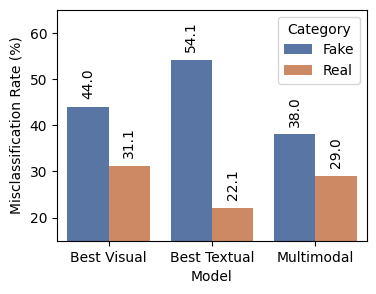

In [187]:
model_names = ['Best Visual', 'Best Textual','Multimodal']
plt.figure(figsize=(4, 3))
#ax = plt.subplot()c
splot = sns.barplot(data=df,x='Models', y='Values' ,hue='Category',palette="deep")
for p in splot.patches:
    splot.annotate(format(p.get_height(), '.1f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 17),
                   textcoords = 'offset points',
                   rotation= 90)

plt.xlabel('Model')
plt.ylabel('Misclassification Rate (%)')
#plt.title('Classwise Misclassification Rate')
plt.ylim([15,65])
plt.xticks([0,1,2],model_names ,rotation = 0)
plt.savefig('ms-rate.png',dpi = 500,bbox_inches ='tight')